# 🐼 Pandas — Clean, Reshape, and Analyze Real Tables

> **What you'll learn:** how to load, explore, select, clean, group, window, join, reshape, and time-slice real datasets with modern pandas 3 idioms (Copy-on-Write, the new string dtype, method chaining) — plus how every operation maps to SQL, and how to avoid the leakage and join bugs that sink real ML projects.

| | |
|---|---|
| **Difficulty** | 🟢 Beginner → 🔴 Advanced (ramps up section by section) |
| **Time** | ~5 hours to read and run, +2 hours for exercises and the project |
| **Prerequisites** | [NumPy](01_NumPy.ipynb) (arrays, boolean masks, vectorization) |
| **Tested with** | Python 3.12 · pandas 3.0 · pyarrow 25 · DuckDB 1.5 (only for the SQL cross-check) · matplotlib |
| **Interview relevance** | ⭐⭐⭐ High — "top-N per group", `groupby` + `transform`, window functions, "why did my row count grow after a merge?", `loc` vs `iloc`, missing data without leakage, SQL ↔ pandas |

## 🤔 What Is Pandas?

**pandas** is Python's library for **tables**. If NumPy is a fast grid of numbers, pandas is a *spreadsheet you control with code*:

- Every column has a **name** and its own **type** (numbers, text, dates, categories).
- Every row has a **label** (the **index**), so pandas can line rows up by label instead of by position.
- Hundreds of operations — filter, group, join, pivot, resample — run on whole columns at once (vectorized, like NumPy).

Two core objects:

```
 Series  = one labelled column          DataFrame = a table of Series sharing one index

 index │ tip                            index │ total_bill │ tip  │ day
 ──────┼──────                          ──────┼────────────┼──────┼─────
   0   │ 1.01                             0   │   16.99    │ 1.01 │ Sun
   1   │ 1.66                             1   │   10.34    │ 1.66 │ Sun
   2   │ 3.50                             2   │   21.01    │ 3.50 │ Sun
```

**Analogy:** a DataFrame is a well-organised spreadsheet where each column is typed, rows have name tags, and instead of clicking through menus you write one line of code that you can re-run tomorrow on next month's data.

## 🎯 Why It Matters

- **Most ML time is data time.** Before any model trains, someone loads, cleans, joins, and aggregates tables — usually in pandas (or SQL, or Polars, which borrow the same ideas).
- **Features are pandas operations.** "Average spend in the last 7 days per user" is a `groupby` + `rolling`; "days since last purchase" is `groupby` + `diff`; "tip rate by hour" is a `pivot_table`.
- **Silent bugs are expensive.** A join on a non-unique key duplicates rows; filling missing values with statistics from the whole dataset leaks test information; chained assignment silently does nothing. Each of these can ruin a model without raising an error.
- **In interviews** data-science and ML-engineer screens often include a live pandas or SQL round: *top-N per group*, *rolling averages per user*, *explain this join's row count*, *translate this SQL to pandas*. This notebook drills exactly those.

## ✅ By the End You Can

- [ ] Load CSV/Parquet data and explore it with `info`, `describe`, and `value_counts`
- [ ] Select, filter, and create columns with `loc`, `iloc`, `query`, `assign`, and method chains that behave correctly under Copy-on-Write
- [ ] Handle missing data and dtypes (category, string, datetime, nullable) without leaking test information
- [ ] Use `groupby` with `agg`, `transform`, `filter`, and window functions (`rank`, `shift`, `diff`, `rolling`, `cumsum`)
- [ ] Join tables safely with `validate=`, reshape with `pivot_table`/`melt`/`stack`, and resample time series
- [ ] Translate SQL to pandas and implement `groupby().mean()` and an inner join from scratch

## 📋 Table of Contents

1. [Series, DataFrame, and the Index](#1.-Series,-DataFrame,-and-the-Index-🟢)
2. [Loading and Exploring Data](#2.-Loading-and-Exploring-Data-🟢)
3. [Selecting Data: loc, iloc, Boolean Filters, query](#3.-Selecting-Data:-loc,-iloc,-Boolean-Filters,-query-🟢)
4. [Creating Columns: assign, Method Chaining, pipe, Copy-on-Write](#4.-Creating-Columns:-assign,-Method-Chaining,-pipe,-Copy-on-Write-🟡)
5. [Missing Data Without Leakage](#5.-Missing-Data-Without-Leakage-🟡)
6. [Data Types: string, category, datetime, nullable](#6.-Data-Types:-string,-category,-datetime,-nullable-🟡)
7. [String and Datetime Operations](#7.-String-and-Datetime-Operations-🟢)
8. [GroupBy: agg, transform, filter](#8.-GroupBy:-agg,-transform,-filter-🟡)
9. [Window Functions Inside Groups](#9.-Window-Functions-Inside-Groups-🔴)
10. [Merging and Joining Safely](#10.-Merging-and-Joining-Safely-🟡)
11. [Reshaping: pivot_table, melt, stack, unstack](#11.-Reshaping:-pivot_table,-melt,-stack,-unstack-🟡)
12. [Time Series: resample and rolling](#12.-Time-Series:-resample-and-rolling-🟡)
13. [Performance: Vectorization vs apply, Measured](#13.-Performance:-Vectorization-vs-apply,-Measured-🟡)
14. [SQL ↔ pandas Translation](#14.-SQL-↔-pandas-Translation-🟢)
- [🔧 Build It From Scratch](#🔧-Build-It-From-Scratch) · [⚠️ Common Pitfalls](#⚠️-Common-Pitfalls) · [🏋️ Practice Exercises](#🏋️-Practice-Exercises) · [🚀 Mini Project](#🚀-Mini-Project:-Cleaning-and-Analyzing-NYC-Taxi-Trips) · [🎤 Interview Q&A](#🎤-Interview-Q&A) · [🧪 Quick Quiz](#🧪-Quick-Quiz) · [📚 Resources](#📚-Resources) · [📝 Summary](#📝-Summary-Cheat-Sheet)

## ⚙️ Setup

Run the cell below first. If a package is missing, uncomment the `%pip` line, run it once, then restart the kernel.

- **Datasets** are real public files, downloaded once and cached in `_outputs/data/`: `tips`, `penguins`, `flights`, `diamonds`, and `taxis` from the [seaborn-data repository](https://github.com/mwaskom/seaborn-data), plus the official NYC taxi zone lookup table from the [NYC Taxi & Limousine Commission](https://www.nyc.gov/site/tlc/about/tlc-trip-record-data.page).
- `check()` gives instant feedback on exercises: **✅** correct, **⏳** not attempted yet, **❌** wrong (with a hint). It understands DataFrames and Series.

In [1]:
# %pip install -q "pandas>=3.0" pyarrow duckdb matplotlib

import sys
import timeit
import urllib.request
import warnings
from pathlib import Path

import duckdb
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

print(f"Python {sys.version.split()[0]} | pandas {pd.__version__} | NumPy {np.__version__} | DuckDB {duckdb.__version__}")

pd.set_option("display.max_columns", 20)
pd.set_option("display.width", 120)
OUTPUT_DIR = Path("_outputs")                         # files we write go here (ignored by git)
DATA_DIR = OUTPUT_DIR / "data"
DATA_DIR.mkdir(parents=True, exist_ok=True)

SEABORN_DATA = "https://raw.githubusercontent.com/mwaskom/seaborn-data/master/{}.csv"
TAXI_ZONES_URL = "https://d37ci6vzurychx.cloudfront.net/misc/taxi_zone_lookup.csv"


def download(url, filename):
    """Download `url` once into _outputs/data/ and return the local path."""
    path = DATA_DIR / filename
    if not path.exists():
        try:
            urllib.request.urlretrieve(url, path)
        except OSError as err:
            raise RuntimeError(f"Could not download {url} — check your internet connection ({err}).") from err
    return path


def check(name, got, expected, hint=""):
    """✅ if correct, ⏳ if not attempted yet (None), ❌ AssertionError with a hint otherwise."""
    if got is None or got is ...:
        print(f"⏳ {name}: not attempted yet — replace None with your answer.")
        return
    try:
        if isinstance(expected, pd.DataFrame):
            pd.testing.assert_frame_equal(got, expected, check_dtype=False, check_names=False, check_exact=False, atol=1e-6)
        elif isinstance(expected, pd.Series):
            pd.testing.assert_series_equal(got, expected, check_dtype=False, check_names=False, check_exact=False, atol=1e-6)
        elif isinstance(expected, float):
            assert np.isclose(got, expected, atol=1e-6), f"got {got!r}"
        else:
            assert got == expected, f"got {got!r}"
    except (AssertionError, TypeError) as err:
        raise AssertionError(f"❌ {name}: not quite. {hint}\n{err}") from None
    print(f"✅ {name}: correct!")

Python 3.12.11 | pandas 3.0.5 | NumPy 2.5.3 | DuckDB 1.5.5


## 1. Series, DataFrame, and the Index 🟢

- A **Series** is a 1-D array of values **plus an index** (the row labels).
- A **DataFrame** is a dict-like collection of Series that share the same index. Selecting one column gives you a Series.
- The index is not decoration: **arithmetic between Series lines values up by label**, not by position. This is called **alignment**.

In [2]:
prices = pd.Series([1.20, 0.50, 3.00], index=["apple", "banana", "cherry"], name="price")
print(prices)
print("\nprices['banana'] =", prices["banana"], "| values:", prices.to_numpy(), "| index:", prices.index.tolist())

stock = pd.DataFrame(
    {"fruit": ["apple", "banana", "cherry"], "price": [1.20, 0.50, 3.00], "qty": [10, 4, 2]}
).set_index("fruit")
print("\n", stock, sep="")
print("\ncolumn types:\n", stock.dtypes, sep="")
print("\none column is a", type(stock["qty"]).__name__, "| shape of the table:", stock.shape)

apple     1.2
banana    0.5
cherry    3.0
Name: price, dtype: float64

prices['banana'] = 0.5 | values: [1.2 0.5 3. ] | index: ['apple', 'banana', 'cherry']

        price  qty
fruit             
apple     1.2   10
banana    0.5    4
cherry    3.0    2

column types:
price    float64
qty        int64
dtype: object

one column is a Series | shape of the table: (3, 2)


In [3]:
morning = pd.Series({"apple": 5, "banana": 3})
afternoon = pd.Series({"banana": 4, "cherry": 7, "apple": 1})   # different order AND an extra label

print("morning + afternoon (aligned by label):\n", morning + afternoon, sep="")
print("\nwith fill_value=0:\n", morning.add(afternoon, fill_value=0), sep="")

morning + afternoon (aligned by label):
apple     6.0
banana    7.0
cherry    NaN
dtype: float64

with fill_value=0:
apple     6.0
banana    7.0
cherry    7.0
dtype: float64


`cherry` became `NaN` ("not a number", pandas' missing-value marker) because `morning` has no cherry label. Alignment prevents "wrong row" bugs, but it can also create unexpected `NaN`s — always check the index when a result has more rows or more missing values than you expected.

### ✍️ Your Turn

`unit_price` and `units_sold` list the same fruits **in a different order**. Compute `revenue` (price × units) as a Series indexed by fruit.

In [4]:
unit_price = pd.Series({"apple": 1.2, "banana": 0.5, "cherry": 3.0})
units_sold = pd.Series({"cherry": 2, "apple": 10, "banana": 4})
revenue = None  # TODO
check("revenue", revenue, pd.Series({"apple": 12.0, "banana": 2.0, "cherry": 6.0}),
      hint="Just multiply the two Series — pandas lines them up by label for you.")

⏳ revenue: not attempted yet — replace None with your answer.


<details><summary>💡 Show solution</summary>

```python
unit_price = pd.Series({"apple": 1.2, "banana": 0.5, "cherry": 3.0})
units_sold = pd.Series({"cherry": 2, "apple": 10, "banana": 4})
revenue = unit_price * units_sold
check("revenue", revenue, pd.Series({"apple": 12.0, "banana": 2.0, "cherry": 6.0}))
```

With NumPy arrays you would have to sort both first; with pandas, the index does it. (`unit_price.to_numpy() * units_sold.to_numpy()` would silently multiply apple by cherry.)
</details>

> 💡 **Interview angle:** "What does the index do?" — it labels rows, enables fast label lookups, and **aligns** data in arithmetic and assignment. Misaligned indexes (e.g. after filtering or sorting) are a classic source of silent `NaN`s; `reset_index(drop=True)` or `.to_numpy()` are the escape hatches.

## 2. Loading and Exploring Data 🟢

`pd.read_csv` reads text files; `pd.read_parquet` reads **Parquet**, a compressed, column-oriented binary format that stores the dtypes too. The first five minutes with any dataset should always be the same checklist:

| Question | Code |
|---|---|
| How big? | `df.shape` |
| What columns and types? Any missing? | `df.info()` |
| What do numbers look like? | `df.describe()` |
| What values do categories take? | `df["col"].value_counts()` |
| Show me some rows | `df.head()`, `df.sample(5)` |

In [5]:
tips = pd.read_csv(download(SEABORN_DATA.format("tips"), "tips.csv"))   # restaurant bills recorded by one waiter
print("shape:", tips.shape)
tips.info()

shape: (244, 7)
<class 'pandas.DataFrame'>
RangeIndex: 244 entries, 0 to 243
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   total_bill  244 non-null    float64
 1   tip         244 non-null    float64
 2   sex         244 non-null    str    
 3   smoker      244 non-null    str    
 4   day         244 non-null    str    
 5   time        244 non-null    str    
 6   size        244 non-null    int64  
dtypes: float64(2), int64(1), str(4)
memory usage: 17.3 KB


In [6]:
tips.head()

,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4


In [7]:
print(tips.describe().round(2))
print("\nday counts:\n", tips["day"].value_counts(), sep="")
print("\nshare of smokers:\n", tips["smoker"].value_counts(normalize=True).round(3), sep="")

       total_bill     tip    size
count      244.00  244.00  244.00
mean        19.79    3.00    2.57
std          8.90    1.38    0.95
min          3.07    1.00    1.00
25%         13.35    2.00    2.00
50%         17.80    2.90    2.00
75%         24.13    3.56    3.00
max         50.81   10.00    6.00

day counts:
day
Sat     87
Sun     76
Thur    62
Fri     19
Name: count, dtype: int64

share of smokers:
smoker
No     0.619
Yes    0.381
Name: proportion, dtype: float64


**CSV vs Parquet.** CSV is human-readable but stores everything as text: pandas must re-parse numbers and re-guess types on every read. Parquet stores typed, compressed columns, so it is smaller, faster, and lets you read only the columns you need. Let's measure on the `diamonds` dataset (~54,000 rows).

In [8]:
diamonds_csv = download(SEABORN_DATA.format("diamonds"), "diamonds.csv")
diamonds = pd.read_csv(diamonds_csv)
parquet_path = OUTPUT_DIR / "diamonds.parquet"
diamonds.to_parquet(parquet_path, index=False)

csv_seconds = min(timeit.repeat(lambda: pd.read_csv(diamonds_csv), number=1, repeat=3))
parquet_seconds = min(timeit.repeat(lambda: pd.read_parquet(parquet_path), number=1, repeat=3))
two_columns = pd.read_parquet(parquet_path, columns=["carat", "price"])

print(f"rows: {len(diamonds):,}")
print(f"file size → CSV {diamonds_csv.stat().st_size / 1e6:.2f} MB | Parquet {parquet_path.stat().st_size / 1e6:.2f} MB")
print(f"read time → CSV {csv_seconds * 1000:.0f} ms | Parquet {parquet_seconds * 1000:.0f} ms")
print("round trip identical:", pd.read_parquet(parquet_path).equals(diamonds), "| column subset:", two_columns.shape)

rows: 53,940
file size → CSV 2.77 MB | Parquet 0.52 MB
read time → CSV 17 ms | Parquet 2 ms
round trip identical: True | column subset: (53940, 2)


> 💡 **Interview angle:** "You get a new dataset — what do you do first?" — `shape`, `info()` (types + missing), `describe()`, `value_counts()` on categoricals, check duplicates and the date range, and only then start modelling. Mention Parquet for anything you read more than once.

## 3. Selecting Data: loc, iloc, Boolean Filters, query 🟢

| Tool | Selects by | Slice end | Example |
|---|---|---|---|
| `df["col"]`, `df[["a", "b"]]` | column name(s) | — | `tips[["tip", "day"]]` |
| `df.loc[rows, cols]` | **labels** (and boolean masks) | **included** | `tips.loc[0:2, "tip"]` → 3 rows |
| `df.iloc[rows, cols]` | **integer positions** | excluded | `tips.iloc[0:2, 1]` → 2 rows |
| `df.query("...")` | a readable boolean expression | — | `tips.query("size >= 4")` |

**Boolean filters** work like NumPy masks: combine conditions with `&` (and), `|` (or), `~` (not), and **wrap each condition in parentheses**.

In [9]:
penguins = pd.read_csv(download(SEABORN_DATA.format("penguins"), "penguins.csv"))   # Palmer Archipelago penguins

print("loc[0:2, ...] (labels, end included):\n", penguins.loc[0:2, ["species", "island", "body_mass_g"]], sep="")
print("\niloc[0:2, 0:3] (positions, end excluded):\n", penguins.iloc[0:2, 0:3], sep="")

heavy_gentoo = penguins.loc[(penguins["species"] == "Gentoo") & (penguins["body_mass_g"] > 5_900),
                            ["species", "sex", "body_mass_g"]]
print("\nheavy Gentoo penguins (boolean mask):\n", heavy_gentoo, sep="")

min_mass = 5_900
same_rows = penguins.query("species == 'Gentoo' and body_mass_g > @min_mass")[["species", "sex", "body_mass_g"]]
print("\nquery() gives the same rows:", same_rows.equals(heavy_gentoo))

print("\nisin + between:", len(penguins[penguins["island"].isin(["Dream", "Torgersen"]) & penguins["bill_length_mm"].between(40, 45)]), "rows")

loc[0:2, ...] (labels, end included):
  species     island  body_mass_g
0  Adelie  Torgersen       3750.0
1  Adelie  Torgersen       3800.0
2  Adelie  Torgersen       3250.0

iloc[0:2, 0:3] (positions, end excluded):
  species     island  bill_length_mm
0  Adelie  Torgersen            39.1
1  Adelie  Torgersen            39.5

heavy Gentoo penguins (boolean mask):
    species   sex  body_mass_g
237  Gentoo  MALE       6300.0
253  Gentoo  MALE       6050.0
297  Gentoo  MALE       6000.0
299  Gentoo  MALE       5950.0
331  Gentoo  MALE       5950.0
337  Gentoo  MALE       6000.0



query() gives the same rows: True

isin + between: 39 rows


### ✍️ Your Turn

Using `tips`, compute the **average tip for Dinner parties of 4 or more people**, rounded to 2 decimals.

In [10]:
big_dinner_tip = None  # TODO
check("big_dinner_tip", big_dinner_tip, 4.11,
      hint="tips.loc[(tips['time'] == 'Dinner') & (tips['size'] >= 4), 'tip'].mean(), then round(..., 2).")

⏳ big_dinner_tip: not attempted yet — replace None with your answer.


<details><summary>💡 Show solution</summary>

```python
big_dinner_tip = round(tips.loc[(tips["time"] == "Dinner") & (tips["size"] >= 4), "tip"].mean(), 2)
check("big_dinner_tip", big_dinner_tip, 4.11)

# the same with query (note: `size` is also a DataFrame attribute, so tips.size would NOT be the column)
check("big_dinner_tip (query)", round(tips.query("time == 'Dinner' and size >= 4")["tip"].mean(), 2), 4.11)
```
</details>

> 💡 **Interview angle:** "`loc` vs `iloc`?" — `loc` is label-based and its slices include the end label; `iloc` is position-based and excludes the end. On a default `RangeIndex` they look similar until you filter or sort — then labels and positions diverge.

## 4. Creating Columns: assign, Method Chaining, pipe, Copy-on-Write 🟡

**Method chaining** writes a transformation as one readable pipeline, top to bottom, without temporary variables:

- `assign(new_col=...)` returns a **new** DataFrame with extra columns (a `lambda d: ...` receives the DataFrame *at that point in the chain*).
- pandas 3 adds `pd.col("name")`, a short way to refer to a column inside `assign`.
- `pipe(func, **kwargs)` inserts your own function into the chain.

**Copy-on-Write (CoW)** is the default — and only — behaviour in pandas 3: *any DataFrame or Series you derive from another behaves like an independent copy*. pandas avoids actually copying until one of them is modified, so it stays fast. The practical rules:

1. Modifying a derived object **never** changes the original.
2. To change the original, assign to it directly: `df.loc[mask, "col"] = value` or `df["col"] = ...`.
3. Chained assignment like `df[mask]["col"] = value` **never works** (more in Pitfalls).

In [11]:
tip_features = (
    tips
    .assign(
        tip_pct=lambda d: d["tip"] / d["total_bill"],       # lambda: column computed from the current frame
        per_person=pd.col("total_bill") / pd.col("size"),    # pandas 3 column expression, same idea
    )
    .query("tip_pct < 0.5")                                  # drop a few implausible outliers
    .sort_values("tip_pct", ascending=False)
    .round({"tip_pct": 3, "per_person": 2})
)
print(tip_features.head())
print("original `tips` is unchanged — columns:", tips.columns.tolist())

     total_bill   tip     sex smoker  day    time  size  tip_pct  per_person
178        9.60  4.00  Female    Yes  Sun  Dinner     2    0.417        4.80
67         3.07  1.00  Female    Yes  Sat  Dinner     1    0.326        3.07
232       11.61  3.39    Male     No  Sat  Dinner     2    0.292        5.80
183       23.17  6.50    Male    Yes  Sun  Dinner     4    0.281        5.79
109       14.31  4.00  Female    Yes  Sat  Dinner     2    0.280        7.16


original `tips` is unchanged — columns: ['total_bill', 'tip', 'sex', 'smoker', 'day', 'time', 'size']


In [12]:
def add_weekend_flag(df, weekend_days=("Sat", "Sun")):
    return df.assign(is_weekend=df["day"].isin(weekend_days))


def mean_by(df, column, by):
    return df.groupby(by)[column].mean().round(3)


print(tip_features.pipe(add_weekend_flag).pipe(mean_by, column="tip_pct", by="is_weekend"))

is_weekend
False    0.163
True     0.156
Name: tip_pct, dtype: float64


In [13]:
bills = tips["total_bill"]                                    # no data copied yet
print("shares memory before any write:", np.shares_memory(bills.to_numpy(), tips["total_bill"].to_numpy()))
bills.iloc[0] = 999.0                                         # the first write triggers the real copy
print("after the write → tips.loc[0, 'total_bill'] is still", tips.loc[0, "total_bill"],
      "| shares memory now:", np.shares_memory(bills.to_numpy(), tips["total_bill"].to_numpy()))

sunday = tips[tips["day"] == "Sun"]
sunday["tip"] = 0.0                                           # changes `sunday` only (no warning in pandas 3)
print("Sunday tips in the original:", tips.loc[tips["day"] == "Sun", "tip"].head(3).tolist())

shares memory before any write: True
after the write → tips.loc[0, 'total_bill'] is still 16.99 | shares memory now: False
Sunday tips in the original: [1.01, 1.66, 3.5]


### ✍️ Your Turn

Starting from `tips`, add a `tip_pct` column (tip ÷ total_bill) and compute the **mean `tip_pct` per `time`** (Lunch/Dinner), rounded to 3 decimals. Return a Series.

In [14]:
tip_pct_by_time = None  # TODO: one method chain
check("tip_pct_by_time", tip_pct_by_time, pd.Series({"Dinner": 0.160, "Lunch": 0.164}),
      hint="tips.assign(tip_pct=...).groupby('time')['tip_pct'].mean().round(3)")

⏳ tip_pct_by_time: not attempted yet — replace None with your answer.


<details><summary>💡 Show solution</summary>

```python
tip_pct_by_time = (
    tips
    .assign(tip_pct=pd.col("tip") / pd.col("total_bill"))
    .groupby("time")["tip_pct"]
    .mean()
    .round(3)
)
check("tip_pct_by_time", tip_pct_by_time, pd.Series({"Dinner": 0.160, "Lunch": 0.164}))
```
</details>

> 💡 **Interview angle:** "What changed with Copy-on-Write in pandas 3?" — every derived object acts as a copy (copies are lazy, made only on write), `SettingWithCopyWarning` is gone, chained assignment never modifies the parent, and `df["col"].method(inplace=True)` doesn't update `df`. Use `df.loc[...] = ...` or reassign the column.

## 5. Missing Data Without Leakage 🟡

pandas marks missing values as `NaN` (floats, and the default string dtype) or `pd.NA` (nullable dtypes). Detect them with `isna()` — **never** with `== np.nan`, because `NaN` is not equal to anything, not even itself.

| Strategy | Code | Good when |
|---|---|---|
| Drop rows | `df.dropna(subset=[...])` | few rows affected, missing at random |
| Fill with a constant | `df.fillna({"sex": "unknown"})` | "missing" is itself informative |
| Fill with a statistic | `df.fillna({"mass": train_median})` | numeric column, moderate missingness |
| Fill per group | `col.fillna(group_key.map(train_group_medians))` | groups differ a lot (e.g. species) |
| Forward-fill | `series.ffill()` | time series sensors |
| Add an indicator | `df.assign(mass_missing=df["mass"].isna())` | missingness might predict the target |

### The leakage rule

**Fill values are learned from data, so learn them from the training set only**, then apply the *same* values to validation and test data. If the fill statistic uses test rows, information from the test set leaks into training, and your test score becomes too optimistic. (It's the same reason you fit a scaler on training data only — in scikit-learn, an imputer inside a `Pipeline` handles this for you.)

In [15]:
print("missing values per column:\n", penguins.isna().sum(), sep="")
print("\nrows with any missing value:\n", penguins[penguins.isna().any(axis=1)].head(4), sep="")

missing values per column:
species               0
island                0
bill_length_mm        2
bill_depth_mm         2
flipper_length_mm     2
body_mass_g           2
sex                  11
dtype: int64

rows with any missing value:
   species     island  bill_length_mm  bill_depth_mm  flipper_length_mm  body_mass_g  sex
3   Adelie  Torgersen             NaN            NaN                NaN          NaN  NaN
8   Adelie  Torgersen            34.1           18.1              193.0       3475.0  NaN
9   Adelie  Torgersen            42.0           20.2              190.0       4250.0  NaN
10  Adelie  Torgersen            37.8           17.1              186.0       3300.0  NaN


In [16]:
split_order = np.random.default_rng(0).permutation(len(penguins))    # reproducible shuffle
cut = int(0.7 * len(penguins))
train_df = penguins.iloc[split_order[:cut]]
test_df = penguins.iloc[split_order[cut:]]
print(f"train {len(train_df)} rows | test {len(test_df)} rows")

flipper_fill = train_df["flipper_length_mm"].mean()                  # learned on TRAIN only
species_mass = train_df.groupby("species")["bill_depth_mm"].median() # per-group statistic, TRAIN only

def fill_missing(df):
    return df.assign(
        flipper_length_mm=df["flipper_length_mm"].fillna(flipper_fill),
        bill_depth_mm=df["bill_depth_mm"].fillna(df["species"].map(species_mass)),
        sex_missing=df["sex"].isna(),                                 # keep the fact that it was missing
        sex=df["sex"].fillna("unknown"),
    )

train_filled, test_filled = fill_missing(train_df), fill_missing(test_df)
print(f"flipper fill value (train mean): {flipper_fill:.2f} | full-data mean would be {penguins['flipper_length_mm'].mean():.2f}")
print("missing after filling → train:", int(train_filled[["flipper_length_mm", "bill_depth_mm", "sex"]].isna().sum().sum()),
      "| test:", int(test_filled[["flipper_length_mm", "bill_depth_mm", "sex"]].isna().sum().sum()))

train 240 rows | test 104 rows
flipper fill value (train mean): 200.52 | full-data mean would be 200.92
missing after filling → train: 0 | test: 0


### ✍️ Your Turn

Using the same `train_df` / `test_df` split, fill missing `body_mass_g` values **in the test set** with the **training-set median**. Store the median in `mass_median` and the filled test column in `test_mass`.

In [17]:
mass_median = None   # TODO: learned from train_df only
test_mass = None     # TODO: test_df["body_mass_g"] with missing values filled
check("mass_fill", None if test_mass is None else (float(mass_median), int(test_mass.isna().sum()), len(test_mass)),
      (3950.0, 0, len(test_df)), hint="train_df['body_mass_g'].median(), then test_df['body_mass_g'].fillna(mass_median).")

⏳ mass_fill: not attempted yet — replace None with your answer.


<details><summary>💡 Show solution</summary>

```python
mass_median = train_df["body_mass_g"].median()
test_mass = test_df["body_mass_g"].fillna(mass_median)
check("mass_fill", (float(mass_median), int(test_mass.isna().sum()), len(test_mass)), (3950.0, 0, len(test_df)))
print("full-data median would have been", penguins["body_mass_g"].median(), "← uses test rows: leakage")
```
</details>

> 💡 **Interview angle:** "How do you handle missing values?" — first ask *why* they're missing; then drop, fill (constant, statistic, per-group, forward-fill), or model them, often adding a missing-indicator column. Say explicitly that **fill statistics come from the training split only** and are reused on validation/test.

## 6. Data Types: string, category, datetime, nullable 🟡

| dtype | Holds | Why use it |
|---|---|---|
| `int64`, `float64`, `bool` | NumPy numbers | fast math; **can't hold missing ints** (they become `float64`) |
| `str` (**new default in pandas 3**) | text | real string type instead of generic `object`; faster, less memory (Arrow-backed when `pyarrow` is installed) |
| `category` | a small set of repeated values | much less memory; can have a meaningful **order** (Fair < Good < Ideal) |
| `datetime64` | timestamps | `.dt` accessor, date arithmetic, resampling |
| `Int64`, `Float64`, `boolean`, `string` (capitalised / nullable) | values **plus** `pd.NA` | integers with missing values stay integers |

In [18]:
print("tips dtypes:\n", tips.dtypes, sep="")
print("\nthe text columns use the pandas 3 string dtype:", tips["day"].dtype, "| missing marker:", tips["day"].dtype.na_value)

ints_with_gap = pd.Series([3, 1, None])
nullable = pd.Series([3, 1, None], dtype="Int64")
print("\nints + None → dtype", ints_with_gap.dtype, ints_with_gap.tolist())
print("nullable Int64 →", nullable.dtype, nullable.tolist())

raw = pd.Series(["12", " 7.5", "n/a", "3 "])
print("\nto_numeric(errors='coerce'):", pd.to_numeric(raw.str.strip(), errors="coerce").tolist())
print("\nconvert_dtypes() picks nullable types:\n", penguins.convert_dtypes().dtypes, sep="")

tips dtypes:
total_bill    float64
tip           float64
sex               str
smoker            str
day               str
time              str
size            int64
dtype: object

the text columns use the pandas 3 string dtype: str | missing marker: nan

ints + None → dtype float64 [3.0, 1.0, nan]
nullable Int64 → Int64 [3, 1, <NA>]

to_numeric(errors='coerce'): [12.0, 7.5, nan, 3.0]

convert_dtypes() picks nullable types:
species               string
island                string
bill_length_mm       Float64
bill_depth_mm        Float64
flipper_length_mm      Int64
body_mass_g            Int64
sex                   string
dtype: object


In [19]:
before_mb = diamonds.memory_usage(deep=True).sum() / 1e6
cut_order = ["Fair", "Good", "Very Good", "Premium", "Ideal"]
diamonds_typed = diamonds.astype({"color": "category", "clarity": "category"}).assign(
    cut=pd.Categorical(diamonds["cut"], categories=cut_order, ordered=True)   # ordered category
)
after_mb = diamonds_typed.memory_usage(deep=True).sum() / 1e6
print(f"diamonds memory: {before_mb:.2f} MB → {after_mb:.2f} MB with categories ({before_mb / after_mb:.1f}× smaller)")
print("ordered comparison — share of cuts at least 'Premium':", round((diamonds_typed["cut"] >= "Premium").mean(), 3))
print("sorted by cut order:", diamonds_typed.sort_values("cut")["cut"].unique().tolist())

diamonds memory: 4.88 MB → 3.18 MB with categories (1.5× smaller)
ordered comparison — share of cuts at least 'Premium': 0.655
sorted by cut order: ['Fair', 'Good', 'Very Good', 'Premium', 'Ideal']


> 💡 **Interview angle:** "Your DataFrame uses 12 GB — what do you do?" — check `memory_usage(deep=True)`, convert repeated strings to `category`, downcast numbers (`float32`, smaller ints), read only needed columns (`usecols`, Parquet `columns=`), and consider chunking or DuckDB/Polars for data bigger than memory.

## 7. String and Datetime Operations 🟢

Vectorized helpers live behind **accessors**: `.str` for text and `.dt` for datetimes. They work on the whole column and skip missing values.

We'll use a real sample of **6,433 New York City taxi trips from March 2019** (yellow and green cabs).

In [20]:
taxis = pd.read_csv(download(SEABORN_DATA.format("taxis"), "taxis.csv"), parse_dates=["pickup", "dropoff"])
print(taxis.dtypes)
taxis.head(3)

pickup             datetime64[us]
dropoff            datetime64[us]
passengers                  int64
distance                  float64
fare                      float64
tip                       float64
tolls                     float64
total                     float64
color                         str
payment                       str
pickup_zone                   str
dropoff_zone                  str
pickup_borough                str
dropoff_borough               str
dtype: object


,pickup,dropoff,passengers,distance,fare,tip,tolls,total,color,payment,pickup_zone,dropoff_zone,pickup_borough,dropoff_borough
0,2019-03-23 20:21:09,2019-03-23 20:27:24,1,1.60,7.0,2.15,0.0,12.95,yellow,credit card,Lenox Hill West,UN/Turtle Bay South,Manhattan,Manhattan
1,2019-03-04 16:11:55,2019-03-04 16:19:00,1,0.79,5.0,0.00,0.0,9.30,yellow,cash,Upper West Side South,Upper West Side South,Manhattan,Manhattan
2,2019-03-27 17:53:01,2019-03-27 18:00:25,1,1.37,7.5,2.36,0.0,14.16,yellow,credit card,Alphabet City,West Village,Manhattan,Manhattan


In [21]:
zones = taxis["pickup_zone"]
print("contains 'Airport':", int(zones.str.contains("Airport", na=False).sum()), "trips")
print("upper-case         :", zones.str.upper().head(2).tolist())
print("first part of 'A/B':", zones[zones.str.contains("/", na=False)].str.split("/").str[0].head(3).tolist())
print("compass suffix     :\n", zones.str.extract(r"(North|South|East|West)$", expand=False).value_counts(), sep="")

contains 'Airport': 297 trips
upper-case         : ['LENOX HILL WEST', 'UPPER WEST SIDE SOUTH']
first part of 'A/B': ['Times Sq', 'Penn Station', 'Penn Station']
compass suffix     :
pickup_zone
South    798
North    798
East     752
West     614
Name: count, dtype: int64


In [22]:
trip_times = taxis.assign(
    duration_min=(taxis["dropoff"] - taxis["pickup"]).dt.total_seconds() / 60,   # Timedelta → minutes
    hour=taxis["pickup"].dt.hour,
    weekday=taxis["pickup"].dt.day_name(),
    pickup_local=taxis["pickup"].dt.tz_localize("America/New_York"),            # attach a time zone
)
print(trip_times[["pickup", "pickup_local", "duration_min", "hour", "weekday"]].head(3))
print("\ndate range:", taxis["pickup"].min(), "→", taxis["pickup"].max())
march_10 = taxis[taxis["pickup"].between("2019-03-10", "2019-03-10 23:59:59")]
print("trips picked up on 10 March:", len(march_10))

               pickup              pickup_local  duration_min  hour    weekday
0 2019-03-23 20:21:09 2019-03-23 20:21:09-04:00      6.250000    20   Saturday
1 2019-03-04 16:11:55 2019-03-04 16:11:55-05:00      7.083333    16     Monday
2 2019-03-27 17:53:01 2019-03-27 17:53:01-04:00      7.400000    17  Wednesday

date range: 2019-02-28 23:29:03 → 2019-03-31 23:43:45
trips picked up on 10 March: 185


> 💡 **Interview angle:** "Parse and engineer date features" — `pd.to_datetime(..., format=...)` (explicit formats are faster and safer), then `.dt.hour`, `.dt.dayofweek`, `.dt.is_month_end`, durations via subtraction and `.dt.total_seconds()`, and time zones with `tz_localize`/`tz_convert`.

## 8. GroupBy: agg, transform, filter 🟡

`groupby` follows **split → apply → combine**:

```
 split by day          apply            combine
 ┌ Fri rows ┐   →   mean(tip)=2.73  ┐
 ├ Sat rows ┤   →   mean(tip)=2.99  ├→  one row per group      ← agg
 ├ Sun rows ┤   →   mean(tip)=3.26  │
 └ Thur rows┘   →   mean(tip)=2.77  ┘
```

| Method | Output size | Use it for |
|---|---|---|
| `.agg(...)` | **one row per group** | summaries: counts, means, max |
| `.transform(...)` | **same length as the input** | adding group statistics back onto each row ("bill vs the day's average") |
| `.filter(func)` | the original rows of groups that pass | "keep only customers with ≥ 5 orders" |

In [23]:
print("mean tip per day:\n", tips.groupby("day")["tip"].mean().round(2), sep="")

summary = tips.groupby(["day", "time"]).agg(          # named aggregation: new_name=(column, function)
    n=("tip", "size"),
    avg_tip=("tip", "mean"),
    max_bill=("total_bill", "max"),
).round(2)
print("\n", summary, sep="")

mean tip per day:
day
Fri     2.73
Sat     2.99
Sun     3.26
Thur    2.77
Name: tip, dtype: float64

              n  avg_tip  max_bill
day  time                         
Fri  Dinner  12     2.94     40.17
     Lunch    7     2.38     16.27
Sat  Dinner  87     2.99     50.81
Sun  Dinner  76     3.26     48.17
Thur Dinner   1     3.00     18.78
     Lunch   61     2.77     43.11


In [24]:
with_group_stats = tips.assign(
    day_avg_tip=tips.groupby("day")["tip"].transform("mean"),
    tip_vs_day=lambda d: (d["tip"] - d["day_avg_tip"]).round(2),
)
print(with_group_stats[["day", "tip", "day_avg_tip", "tip_vs_day"]].head(4).round(2))
print("transform keeps the length:", len(with_group_stats) == len(tips))

busy_days = tips.groupby("day").filter(lambda g: len(g) >= 70)
print("\nfilter → days with ≥ 70 bills:", busy_days["day"].unique().tolist(), f"({len(busy_days)} of {len(tips)} rows kept)")

   day   tip  day_avg_tip  tip_vs_day
0  Sun  1.01         3.26       -2.25
1  Sun  1.66         3.26       -1.60
2  Sun  3.50         3.26        0.24
3  Sun  3.31         3.26        0.05
transform keeps the length: True

filter → days with ≥ 70 bills: ['Sun', 'Sat'] (163 of 244 rows kept)


### ✍️ Your Turn

Create `bill_share`: each bill's `total_bill` divided by the **sum of all bills on the same day** (a Series with the same length as `tips`).

In [25]:
bill_share = None  # TODO
check("bill_share", None if bill_share is None else (len(bill_share), bill_share.round(4).head(3).tolist()),
      (len(tips), [0.0104, 0.0064, 0.0129]), hint="tips['total_bill'] / tips.groupby('day')['total_bill'].transform('sum')")

⏳ bill_share: not attempted yet — replace None with your answer.


<details><summary>💡 Show solution</summary>

```python
bill_share = tips["total_bill"] / tips.groupby("day")["total_bill"].transform("sum")
check("bill_share", (len(bill_share), bill_share.round(4).head(3).tolist()), (len(tips), [0.0104, 0.0064, 0.0129]))
print("shares within each day sum to 1:", bill_share.groupby(tips["day"]).sum().round(6).unique())
```
`agg("sum")` would give only 4 numbers (one per day); `transform("sum")` broadcasts them back to all 244 rows so the division lines up.
</details>

> 💡 **Interview angle:** "`agg` vs `transform`?" — `agg` reduces each group to one row; `transform` returns a result aligned to the original rows, which is how you build features like "user's average order value" without a merge.

## 9. Window Functions Inside Groups 🔴

A **window function** computes a value for each row using *other rows around it* — without collapsing rows like `agg` does. In SQL it's `... OVER (PARTITION BY year ORDER BY month)`; in pandas it's **sort, then `groupby(...)` + a window method**.

| SQL | pandas (after sorting) | Meaning |
|---|---|---|
| `ROW_NUMBER()` | `g.cumcount() + 1` | 1, 2, 3 … within the group |
| `RANK()` / `DENSE_RANK()` | `g["x"].rank(method="min" / "dense")` | ties share a rank |
| `LAG(x)` / `LEAD(x)` | `g["x"].shift(1)` / `shift(-1)` | previous / next row's value |
| `x - LAG(x)` | `g["x"].diff()` | change since previous row |
| `SUM(x) OVER (... ROWS UNBOUNDED PRECEDING)` | `g["x"].cumsum()` | running total |
| `AVG(x) OVER (... ROWS 2 PRECEDING)` | `g["x"].transform(lambda s: s.rolling(3).mean())` | moving average |
| expanding max | `g["x"].cummax()` / `expanding().max()` | best so far |

The `flights` dataset has monthly airline passengers (in thousands) from 1949 to 1960.

In [26]:
flights = pd.read_csv(download(SEABORN_DATA.format("flights"), "flights.csv"))
flights = (
    flights
    .assign(date=pd.to_datetime(flights["year"].astype(str) + "-" + flights["month"], format="%Y-%B"))
    .sort_values("date")                          # window functions need a defined order
    .reset_index(drop=True)
)
by_year = flights.groupby("year")["passengers"]

windowed = flights.assign(
    rank_in_year=by_year.rank(ascending=False, method="dense").astype(int),   # 1 = busiest month of that year
    prev_month=by_year.shift(1),                                               # LAG within the year
    running_total=by_year.cumsum(),
    rolling_3m=by_year.transform(lambda s: s.rolling(3, min_periods=1).mean()).round(1),
    best_so_far=by_year.cummax(),
    same_month_last_year=flights.groupby("month")["passengers"].shift(1),     # partition by MONTH instead
)
windowed.iloc[10:16]

,year,month,passengers,date,rank_in_year,prev_month,running_total,rolling_3m,best_so_far,same_month_last_year
10,1949,November,104,1949-11-01,10,119.0,1402,119.7,148,NaN
11,1949,December,118,1949-12-01,8,104.0,1520,113.7,148,NaN
12,1950,January,115,1950-01-01,10,NaN,115,115.0,115,112.0
13,1950,February,126,1950-02-01,8,115.0,241,120.5,126,118.0
14,1950,March,141,1950-03-01,4,126.0,382,127.3,141,132.0
15,1950,April,135,1950-04-01,6,141.0,517,134.0,141,129.0


**Leakage warning for features.** If you predict *this* month's passengers, a rolling mean that *includes* this month uses the answer. Shift first so each row only sees the past:

In [27]:
features = flights.assign(
    leaky_rolling_3m=by_year.transform(lambda s: s.rolling(3).mean()),
    past_rolling_3m=by_year.transform(lambda s: s.shift(1).rolling(3).mean()),   # only months BEFORE this row
)
row = features.iloc[15]
print(f"{row['date']:%b %Y}: passengers={row['passengers']} | leaky 3-month mean={row['leaky_rolling_3m']:.1f} "
      f"(includes this month) | past-only={row['past_rolling_3m']:.1f}")
print("overall expanding mean after 3 years:", round(flights["passengers"].expanding().mean().iloc[35], 1))

Apr 1950: passengers=135 | leaky 3-month mean=134.0 (includes this month) | past-only=127.3
overall expanding mean after 3 years: 145.5


### ✍️ Your Turn

Create `mom_change`: the **month-over-month change in passengers, restarting every year** (so each January is `NaN`). `flights` is already sorted by date.

In [28]:
mom_change = None  # TODO
check("mom_change", None if mom_change is None else (mom_change.iloc[12:16].isna().tolist(), mom_change.iloc[13:16].tolist()),
      ([True, False, False, False], [11.0, 15.0, -6.0]), hint="Group by year, then use .diff() on passengers.")

⏳ mom_change: not attempted yet — replace None with your answer.


<details><summary>💡 Show solution</summary>

```python
mom_change = flights.groupby("year")["passengers"].diff()
check("mom_change", (mom_change.iloc[12:16].isna().tolist(), mom_change.iloc[13:16].tolist()),
      ([True, False, False, False], [11.0, 15.0, -6.0]))
```
Without the `groupby`, January 1950 would be compared with December 1949 — sometimes you want that, but then it isn't "restarting every year".
</details>

> 💡 **Interview angle:** "Compute each user's days since their previous order" — `df.sort_values(["user", "ts"]).groupby("user")["ts"].diff().dt.days`. Say *sort first*, and for ML features *shift before rolling* so a row never sees its own label.

## 10. Merging and Joining Safely 🟡

`left.merge(right, on=key, how=...)` combines tables like SQL `JOIN`:

| `how=` | Keeps |
|---|---|
| `"inner"` | only keys present in both |
| `"left"` | every left row (unmatched → `NaN`) |
| `"right"` | every right row |
| `"outer"` | every row from both |

**The row-explosion rule:** if a key appears *m* times on the left and *n* times on the right, the join outputs **m × n** rows for it. A lookup table that you *believe* has unique keys but doesn't will silently duplicate your data. Protect every join with **`validate=`** (`"one_to_one"`, `"many_to_one"`, …), and use `indicator=True` to see where rows came from.

We'll join taxi trips to the official **taxi zone lookup table**.

In [29]:
zone_lookup = pd.read_csv(download(TAXI_ZONES_URL, "taxi_zone_lookup.csv"))
print(zone_lookup.head(3))
print(f"\n{len(zone_lookup)} zones | duplicated zone names: {zone_lookup['Zone'].duplicated().sum()}")
print(zone_lookup[zone_lookup["Zone"].duplicated(keep=False)])

   LocationID Borough                     Zone service_zone
0           1     EWR           Newark Airport          EWR
1           2  Queens              Jamaica Bay    Boro Zone
2           3   Bronx  Allerton/Pelham Gardens    Boro Zone

265 zones | duplicated zone names: 3
     LocationID    Borough                                           Zone service_zone
55           56     Queens                                         Corona    Boro Zone
56           57     Queens                                         Corona    Boro Zone
102         103  Manhattan  Governor's Island/Ellis Island/Liberty Island  Yellow Zone
103         104  Manhattan  Governor's Island/Ellis Island/Liberty Island  Yellow Zone
104         105  Manhattan  Governor's Island/Ellis Island/Liberty Island  Yellow Zone


In [30]:
left_demo = pd.DataFrame({"zone": ["Midtown Center", "JFK Airport", "Atlantis"], "trips": [3, 5, 1]})
right_demo = zone_lookup[["Zone", "Borough"]].rename(columns={"Zone": "zone"})
for how in ("inner", "left"):
    joined = left_demo.merge(right_demo, on="zone", how=how, indicator=True)
    print(f"how='{how}': {len(joined)} rows | {joined['_merge'].value_counts().to_dict()}")

how='inner': 2 rows | {'both': 2, 'left_only': 0, 'right_only': 0}
how='left': 3 rows | {'both': 2, 'left_only': 1, 'right_only': 0}


In [31]:
exploded = taxis.merge(zone_lookup[["Borough", "service_zone"]], left_on="pickup_borough", right_on="Borough")
print(f"❌ joining on borough (not unique in the lookup): {len(taxis):,} trips → {len(exploded):,} rows "
      f"({len(exploded) / len(taxis):.0f}× more)")

by_zone_name = taxis.merge(zone_lookup, left_on="dropoff_zone", right_on="Zone", how="left")
print(f"❌ joining on zone name: {len(by_zone_name) - len(taxis)} extra rows, caused only by the duplicated names above")

try:
    taxis.merge(zone_lookup, left_on="dropoff_zone", right_on="Zone", how="left", validate="many_to_one")
except pd.errors.MergeError as err:
    print("✅ validate='many_to_one' catches it → MergeError:", str(err).splitlines()[0])

❌ joining on borough (not unique in the lookup): 6,433 trips → 436,471 rows (68× more)
❌ joining on zone name: 5 extra rows, caused only by the duplicated names above


✅ validate='many_to_one' catches it → MergeError: Merge keys are not unique in right dataset; not a many-to-one merge


### ✍️ Your Turn

Build `trips_with_zone`: every taxi trip with the `service_zone` of its **pickup** zone. First make a lookup with **unique zone names** (keep the first occurrence), then left-join with `validate="many_to_one"`. The row count must stay 6,433.

In [32]:
trips_with_zone = None  # TODO
check("trips_with_zone", None if trips_with_zone is None else (len(trips_with_zone), int((trips_with_zone["service_zone"] == "Yellow Zone").sum())),
      (6433, 4854), hint="zone_lookup.drop_duplicates(subset='Zone') then taxis.merge(..., left_on='pickup_zone', right_on='Zone', how='left', validate='many_to_one').")

⏳ trips_with_zone: not attempted yet — replace None with your answer.


<details><summary>💡 Show solution</summary>

```python
unique_zones = zone_lookup.drop_duplicates(subset="Zone", keep="first")[["Zone", "service_zone"]]
trips_with_zone = taxis.merge(unique_zones, left_on="pickup_zone", right_on="Zone", how="left", validate="many_to_one")
check("trips_with_zone", (len(trips_with_zone), int((trips_with_zone["service_zone"] == "Yellow Zone").sum())), (6433, 4854))
```
In a real pipeline you'd join on the numeric `LocationID` instead of names — names are for humans, IDs are for joins.
</details>

> 💡 **Interview angle:** "After a join my row count went up — why?" — duplicate keys in the right table (m × n rows per key). Check `right[key].duplicated().sum()`, pass `validate="many_to_one"`, and compare `len()` before and after every join. Also note: unlike SQL, pandas matches missing (`NaN`) keys to each other.

## 11. Reshaping: pivot_table, melt, stack, unstack 🟡

```
  LONG (tidy): one row per observation           WIDE: one row per year, one column per month
  year │ month    │ passengers                    year │ January │ February │ …
  1949 │ January  │ 112           pivot  →        1949 │   112   │   118    │
  1949 │ February │ 118           ←  melt         1950 │   115   │   126    │
```

- `pivot(index, columns, values)` — long → wide when each (index, column) pair is unique.
- `pivot_table(..., aggfunc=)` — long → wide **with aggregation** when pairs repeat.
- `melt(id_vars, var_name, value_name)` — wide → long (most plotting and ML code wants long).
- `unstack()` / `stack()` — move an index level to columns / back.

In [33]:
month_order = flights["month"].unique().tolist()          # January … December, in date order
wide = flights.pivot(index="year", columns="month", values="passengers")[month_order]
print("wide shape:", wide.shape)
print(wide.iloc[:3, :6])

try:
    tips.pivot(index="day", columns="time", values="tip")  # many bills per (day, time)
except ValueError as err:
    print("\npivot with repeated pairs → ValueError:", err)

print("\npivot_table (mean tip):\n", tips.pivot_table(index="day", columns="time", values="tip", aggfunc="mean", margins=True).round(2), sep="")

wide shape: (12, 12)
month  January  February  March  April  May  June
year                                             
1949       112       118    132    129  121   135
1950       115       126    141    135  125   149
1951       145       150    178    163  172   178

pivot with repeated pairs → ValueError: Index contains duplicate entries, cannot reshape



pivot_table (mean tip):
time  Dinner  Lunch   All
day                      
Fri     2.94   2.38  2.73
Sat     2.99    NaN  2.99
Sun     3.26    NaN  3.26
Thur    3.00   2.77  2.77
All     3.10   2.73  3.00


In [34]:
day_time = tips.groupby(["day", "time"])["tip"].mean().round(2)       # a Series with a 2-level index
print("unstack('time'):\n", day_time.unstack("time"), sep="")
print("\nstack() back — note it keeps the missing combinations as NaN:\n", day_time.unstack("time").stack(), sep="")
print("\ncrosstab (share of each day's bills by time):\n", pd.crosstab(tips["day"], tips["time"], normalize="index").round(2), sep="")

unstack('time'):
time  Dinner  Lunch
day                
Fri     2.94   2.38
Sat     2.99    NaN
Sun     3.26    NaN
Thur    3.00   2.77

stack() back — note it keeps the missing combinations as NaN:
day   time  
Fri   Dinner    2.94
      Lunch     2.38
Sat   Dinner    2.99
      Lunch      NaN
Sun   Dinner    3.26
      Lunch      NaN
Thur  Dinner    3.00
      Lunch     2.77
dtype: float64

crosstab (share of each day's bills by time):
time  Dinner  Lunch
day                
Fri     0.63   0.37
Sat     1.00   0.00
Sun     1.00   0.00
Thur    0.02   0.98


### ✍️ Your Turn

Turn `wide` (years × months) back into a **long** DataFrame `long_flights` with columns `year`, `month`, `passengers`.

In [35]:
long_flights = None  # TODO
check("long_flights", None if long_flights is None else (long_flights.shape, sorted(long_flights.columns), int(long_flights["passengers"].sum())),
      ((144, 3), ["month", "passengers", "year"], 40363), hint="wide.reset_index().melt(id_vars='year', var_name='month', value_name='passengers')")

⏳ long_flights: not attempted yet — replace None with your answer.


<details><summary>💡 Show solution</summary>

```python
long_flights = wide.reset_index().melt(id_vars="year", var_name="month", value_name="passengers")
check("long_flights", (long_flights.shape, sorted(long_flights.columns), int(long_flights["passengers"].sum())),
      ((144, 3), ["month", "passengers", "year"], 40363))
```
`reset_index()` turns the `year` index back into a column so `melt` can keep it as an identifier.
</details>

> 💡 **Interview angle:** "`pivot` vs `pivot_table`?" — `pivot` only reshapes and fails on duplicate index/column pairs; `pivot_table` aggregates duplicates (`aggfunc`), can add totals (`margins=True`), and is the pandas version of a spreadsheet pivot / SQL `GROUP BY` + `CASE WHEN`.

## 12. Time Series: resample and rolling 🟡

With a `DatetimeIndex` (or `on="date_column"`), **`resample(rule)`** is a `groupby` over time buckets: `"D"` day, `"W"` week, `"ME"` month end, `"QE"` quarter end, `"YE"` year end. **`rolling(n)`** smooths a series over the last *n* rows (or a time span like `"7D"`).

In [36]:
monthly = flights.set_index("date")["passengers"]
print("quarterly totals:\n", monthly.resample("QE").sum().head(4), sep="")
yearly = monthly.resample("YE").sum()
growth = yearly.pct_change().mul(100).round(1)
print(f"\nyear-over-year growth: min {growth.min()}% ({growth.idxmin():%Y}) | max {growth.max()}% ({growth.idxmax():%Y})")

daily_trips = taxis.resample("D", on="pickup").size()
print("\ntaxi trips per day (first week):\n", daily_trips["2019-03-01":"2019-03-07"], sep="")
print("busiest weekday on average:", daily_trips.groupby(daily_trips.index.day_name()).mean().idxmax())

quarterly totals:
date
1949-03-31    362
1949-06-30    385
1949-09-30    432
1949-12-31    341
Freq: QE-DEC, Name: passengers, dtype: int64

year-over-year growth: min 3.4% (1958) | max 21.8% (1951)

taxi trips per day (first week):
pickup
2019-03-01    241
2019-03-02    198
2019-03-03    169
2019-03-04    171
2019-03-05    228
2019-03-06    257
2019-03-07    218
Freq: D, dtype: int64


busiest weekday on average: Wednesday


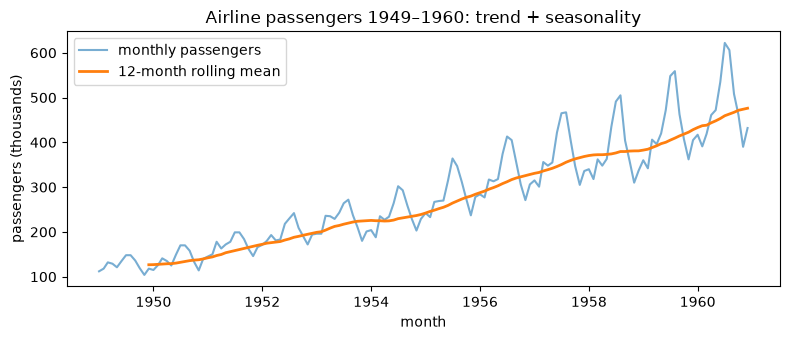

In [37]:
fig, ax = plt.subplots(figsize=(8, 3.5))
ax.plot(monthly.index, monthly, label="monthly passengers", alpha=0.6)
ax.plot(monthly.index, monthly.rolling(12).mean(), label="12-month rolling mean", linewidth=2)
ax.set(title="Airline passengers 1949–1960: trend + seasonality", xlabel="month", ylabel="passengers (thousands)")
ax.legend()
plt.tight_layout()
plt.show()

> 💡 **Interview angle:** "Aggregate event logs to daily active users with a 7-day average" — parse timestamps, `resample("D", on="ts")["user_id"].nunique()`, then `.rolling(7).mean()`; mention time zones and that missing days appear as 0 rows in `resample` (unlike `groupby` on dates).

## 13. Performance: Vectorization vs apply, Measured 🟡

pandas is fast when the loop runs **inside** pandas/NumPy (compiled code over whole columns). `df.apply(func, axis=1)` and `iterrows()` call a Python function **once per row**, so they are slow — convenient, but a last resort.

| Instead of | Use |
|---|---|
| `df.apply(lambda r: r.a / r.b, axis=1)` | `df["a"] / df["b"]` |
| `s.apply(lambda x: "hi" if x > 5 else "lo")` | `np.where(s > 5, "hi", "lo")` |
| nested if/elif in `apply` | `np.select([cond1, cond2], [v1, v2], default=v3)` or `pd.cut` |
| `s.apply(lambda x: mapping[x])` | `s.map(mapping)` |
| `for _, row in df.iterrows()` | vectorized columns, or `itertuples()` if you truly must loop |

In [38]:
def best_seconds(fn, repeat=3):
    return min(timeit.repeat(fn, number=1, repeat=repeat))


t_apply = best_seconds(lambda: diamonds.apply(lambda r: r["price"] / r["carat"], axis=1))
t_vector = best_seconds(lambda: diamonds["price"] / diamonds["carat"])
assert np.allclose(diamonds.apply(lambda r: r["price"] / r["carat"], axis=1), diamonds["price"] / diamonds["carat"])

t_apply_label = best_seconds(lambda: diamonds["price"].apply(lambda p: "expensive" if p > 5000 else "cheap"))
t_where = best_seconds(lambda: np.where(diamonds["price"] > 5000, "expensive", "cheap"))

sample = diamonds.head(10_000)
t_iterrows = best_seconds(lambda: sum(row["price"] for _, row in sample.iterrows()), repeat=1)
t_sum = best_seconds(lambda: sample["price"].sum())

print(f"price per carat on {len(diamonds):,} rows → apply(axis=1) {t_apply * 1000:.0f} ms | vectorized {t_vector * 1000:.2f} ms "
      f"→ {t_apply / t_vector:,.0f}× faster")
print(f"if/else label          → Series.apply {t_apply_label * 1000:.1f} ms | np.where {t_where * 1000:.1f} ms "
      f"→ {t_apply_label / t_where:.0f}× faster")
print(f"sum of 10,000 prices   → iterrows {t_iterrows * 1000:.0f} ms | .sum() {t_sum * 1000:.3f} ms "
      f"→ {t_iterrows / t_sum:,.0f}× faster")

price per carat on 53,940 rows → apply(axis=1) 122 ms | vectorized 0.07 ms → 1,775× faster
if/else label          → Series.apply 5.2 ms | np.where 0.4 ms → 12× faster
sum of 10,000 prices   → iterrows 87 ms | .sum() 0.017 ms → 5,274× faster


### ✍️ Your Turn

Label every diamond with a price band **without `apply`**: `"budget"` if price < 1000, `"mid"` if price < 5000, otherwise `"premium"`. Store the labels (array or Series) in `price_band`.

In [39]:
price_band = None  # TODO
check("price_band", None if price_band is None else pd.Series(price_band).value_counts().to_dict(),
      {"mid": 24714, "premium": 14727, "budget": 14499},
      hint="np.select([diamonds['price'] < 1000, diamonds['price'] < 5000], ['budget', 'mid'], default='premium')")

⏳ price_band: not attempted yet — replace None with your answer.


<details><summary>💡 Show solution</summary>

```python
price_band = np.select(
    [diamonds["price"] < 1000, diamonds["price"] < 5000],
    ["budget", "mid"],
    default="premium",
)
check("price_band", pd.Series(price_band).value_counts().to_dict(), {"mid": 24714, "premium": 14727, "budget": 14499})

# pd.cut does the same with bin edges (right=False makes the bins [a, b)):
bands_cut = pd.cut(diamonds["price"], bins=[0, 1000, 5000, np.inf], labels=["budget", "mid", "premium"], right=False)
check("price_band (pd.cut)", bands_cut.astype(str).value_counts().to_dict(), {"mid": 24714, "premium": 14727, "budget": 14499})
```
`np.select` checks conditions in order, so `price < 5000` only applies to rows that weren't already `budget`.
</details>

> 💡 **Interview angle:** "This pandas job takes an hour" — profile first, then remove row-wise `apply`/`iterrows` in favour of vectorized ops, `map`, `np.where`/`np.select`, use categorical dtypes and Parquet, and move to DuckDB/Polars (multi-threaded, larger-than-memory) when a single pandas process is the bottleneck.

## 14. SQL ↔ pandas Translation 🟢

| SQL | pandas |
|---|---|
| `SELECT a, b FROM t` | `t[["a", "b"]]` |
| `WHERE a > 1 AND b = 'x'` | `t.loc[(t["a"] > 1) & (t["b"] == "x")]` or `t.query("a > 1 and b == 'x'")` |
| `GROUP BY k` + `COUNT(*)`, `AVG(v)` | `t.groupby("k").agg(n=("v", "size"), avg=("v", "mean"))` |
| `HAVING COUNT(*) > 30` | filter **after** the aggregation: `.loc[lambda d: d["n"] > 30]` |
| `ORDER BY v DESC LIMIT 5` | `.sort_values("v", ascending=False).head(5)` or `.nlargest(5, "v")` |
| `SELECT DISTINCT k` / `COUNT(DISTINCT k)` | `t["k"].drop_duplicates()` / `t["k"].nunique()` |
| `CASE WHEN … THEN … ELSE … END` | `np.select(...)` / `np.where(...)` |
| `a INNER / LEFT JOIN b ON a.k = b.k` | `a.merge(b, on="k", how="inner" / "left")` |
| `UNION ALL` | `pd.concat([a, b], ignore_index=True)` |
| `COALESCE(x, 0)` / `x IS NULL` | `t["x"].fillna(0)` / `t["x"].isna()` |
| `x LIKE '%air%'` | `t["x"].str.contains("air")` |
| `ROW_NUMBER() OVER (PARTITION BY k ORDER BY v DESC)` | `t.sort_values("v", ascending=False).groupby("k").cumcount() + 1` |
| `LAG(v) OVER (PARTITION BY k ORDER BY ts)` | `t.sort_values("ts").groupby("k")["v"].shift(1)` |

DuckDB can run SQL **directly on a pandas DataFrame** in memory, so we can prove each translation gives identical results.

In [40]:
sql_query = """
SELECT day, COUNT(*) AS n, AVG(tip) AS avg_tip
FROM tips
WHERE size >= 2
GROUP BY day
HAVING COUNT(*) > 30
ORDER BY avg_tip DESC
"""
from_sql = duckdb.sql(sql_query).df()

from_pandas = (
    tips.loc[tips["size"] >= 2]
    .groupby("day", as_index=False)
    .agg(n=("tip", "size"), avg_tip=("tip", "mean"))
    .loc[lambda d: d["n"] > 30]
    .sort_values("avg_tip", ascending=False)
    .reset_index(drop=True)
)
pd.testing.assert_frame_equal(from_sql, from_pandas, check_dtype=False)
print("✅ SQL and pandas agree:\n", from_pandas.round(3), sep="")

✅ SQL and pandas agree:
    day   n  avg_tip
0   Sun  76    3.255
1   Sat  85    3.040
2  Thur  61    2.787


In [41]:
lag_sql = duckdb.sql("""
    SELECT year, month, passengers,
           LAG(passengers) OVER (PARTITION BY month ORDER BY year) AS same_month_last_year
    FROM flights
    ORDER BY year, month
""").df()
lag_pandas = (
    flights.sort_values("year")
    .assign(same_month_last_year=lambda d: d.groupby("month")["passengers"].shift(1))
    [["year", "month", "passengers", "same_month_last_year"]]
    .sort_values(["year", "month"])
    .reset_index(drop=True)
)
pd.testing.assert_frame_equal(lag_sql, lag_pandas, check_dtype=False)
print("✅ LAG window function matches groupby().shift():\n", lag_pandas.iloc[12:15], sep="")

✅ LAG window function matches groupby().shift():
    year     month  passengers  same_month_last_year
12  1950     April         135                 129.0
13  1950    August         170                 148.0
14  1950  December         140                 118.0


> 💡 **Interview angle:** Many interviews let you choose SQL or pandas. Knowing both lets you say: *"In SQL this is a `ROW_NUMBER` window; in pandas I'd sort and use `groupby().cumcount()`"* — and to point out differences such as pandas matching `NaN` join keys while SQL `NULL`s never match.

## 🔧 Build It From Scratch

Interviewers sometimes ask *"how would you implement group-by / join without pandas?"* — it tests whether you understand hashing and complexity, not just the API.

### 1) `groupby().mean()` — plain Python and NumPy

- **Plain Python:** one pass with two dictionaries (sum and count per key) → O(n).
- **NumPy:** turn keys into integer codes with `np.unique(..., return_inverse=True)`, then `np.bincount` sums values per code in compiled code.

Like pandas, both skip rows whose key or value is missing.

In [42]:
def groupby_mean_python(keys, values):
    totals, counts = {}, {}
    for key, value in zip(keys, values):
        if pd.isna(key) or pd.isna(value):          # pandas drops NaN keys and skips NaN values
            continue
        totals[key] = totals.get(key, 0.0) + value
        counts[key] = counts.get(key, 0) + 1
    return {key: totals[key] / counts[key] for key in sorted(totals)}


def groupby_mean_numpy(keys, values):
    keys = np.asarray(keys, dtype=object)
    values = np.asarray(values, dtype=float)
    valid = ~pd.isna(keys) & ~np.isnan(values)
    uniques, codes = np.unique(keys[valid], return_inverse=True)    # "Adelie" → 0, "Chinstrap" → 1, ...
    sums = np.bincount(codes, weights=values[valid])
    counts = np.bincount(codes)
    return pd.Series(sums / counts, index=uniques)


# Real data with missing keys AND missing values
expected_by_sex = penguins.groupby("sex")["body_mass_g"].mean()
ours_py = groupby_mean_python(penguins["sex"], penguins["body_mass_g"])
ours_np = groupby_mean_numpy(penguins["sex"], penguins["body_mass_g"])
assert list(ours_py) == expected_by_sex.index.tolist() and np.allclose(list(ours_py.values()), expected_by_sex)
pd.testing.assert_series_equal(ours_np, expected_by_sex, check_names=False, check_index_type=False)

# Two keys at once: tuples are hashable, so they work as dict keys
two_keys = groupby_mean_python(zip(tips["day"], tips["time"]), tips["tip"])
expected_two = tips.groupby(["day", "time"])["tip"].mean()
assert list(two_keys) == expected_two.index.tolist() and np.allclose(list(two_keys.values()), expected_two)

t_py = best_seconds(lambda: groupby_mean_python(diamonds["cut"], diamonds["price"]))
t_np = best_seconds(lambda: groupby_mean_numpy(diamonds["cut"], diamonds["price"]))
t_pd = best_seconds(lambda: diamonds.groupby("cut")["price"].mean())
print("✅ both match pandas (including missing values and two keys):\n", ours_np.round(1), sep="")
print(f"\n54k diamonds → plain Python {t_py * 1000:.0f} ms | NumPy {t_np * 1000:.1f} ms | pandas {t_pd * 1000:.1f} ms")

✅ both match pandas (including missing values and two keys):
FEMALE    3862.3
MALE      4545.7
dtype: float64

54k diamonds → plain Python 32 ms | NumPy 17.1 ms | pandas 1.1 ms


### 2) An inner join — the hash join

Databases and pandas join tables with a **hash join**:
1. **Build:** put the right table into a dict `key → list of rows` — O(m).
2. **Probe:** for each left row, look up its key and emit one output row per match — O(n) plus the output size.

Duplicate keys on the right produce multiple matches: that is exactly where row explosion comes from. We test on real trips joined to the zone lookup (which has duplicate names).

In [43]:
def hash_inner_join(left, right, left_on, right_on):
    buckets = {}
    for right_row in right.to_dict("records"):                     # build phase
        buckets.setdefault(right_row[right_on], []).append(right_row)
    output = []
    for left_row in left.to_dict("records"):                       # probe phase
        for match in buckets.get(left_row[left_on], []):
            output.append({**left_row, **match})
    return pd.DataFrame(output)


trips_small = taxis.reset_index(names="trip_id")[["trip_id", "dropoff_zone", "fare"]].dropna()
zones_small = zone_lookup[["LocationID", "Zone", "Borough"]].dropna()

ours = hash_inner_join(trips_small, zones_small, left_on="dropoff_zone", right_on="Zone")
theirs = trips_small.merge(zones_small, left_on="dropoff_zone", right_on="Zone", how="inner")
sort_cols = ["trip_id", "LocationID"]
pd.testing.assert_frame_equal(
    ours.sort_values(sort_cols).reset_index(drop=True)[theirs.columns],
    theirs.sort_values(sort_cols).reset_index(drop=True),
    check_dtype=False,
)
print(f"✅ hash join matches pd.merge: {len(trips_small):,} trips × {len(zones_small)} zones → {len(ours):,} rows "
      f"({len(ours) - trips_small['dropoff_zone'].isin(zones_small['Zone']).sum()} extra rows from duplicate zone names)")

✅ hash join matches pd.merge: 6,388 trips × 263 zones → 6,393 rows (5 extra rows from duplicate zone names)


## ⚠️ Common Pitfalls

### ❌ Pitfall 1 — Chained assignment and `inplace` on a column (silently does nothing in pandas 3)

In [44]:
df = penguins.copy()
with warnings.catch_warnings(record=True) as caught:
    warnings.simplefilter("always")
    df["sex"].fillna("unknown", inplace=True)                       # ❌ works on a temporary copy
    df[df["body_mass_g"] > 6000]["body_mass_g"] = 6000              # ❌ also a temporary copy
print("❌ missing sex values still:", int(df["sex"].isna().sum()),
      "| masses above 6000 still:", int((df["body_mass_g"] > 6000).sum()))
print("   pandas emitted:", sorted({w.category.__name__ for w in caught}) or "no warning")

df = df.fillna({"sex": "unknown"})                                  # ✅ reassign the result
df.loc[df["body_mass_g"] > 6000, "body_mass_g"] = 6000              # ✅ one .loc call on the original
print("✅ missing sex values:", int(df["sex"].isna().sum()), "| masses above 6000:", int((df["body_mass_g"] > 6000).sum()))

❌ missing sex values still: 11 | masses above 6000 still: 2
   pandas emitted: ['ChainedAssignmentError']
✅ missing sex values: 0 | masses above 6000: 0


### ❌ Pitfall 2 — Computing encodings or fill values on the full dataset (leakage)

Here we predict a bill's tip from the average tip of bills with the same rounded amount (a "target encoding"). Computing those averages on *all* rows lets test tips leak into the feature.

In [45]:
bill_bucket = tips["total_bill"].round()
order = np.random.default_rng(1).permutation(len(tips))
train_idx, test_idx = order[:170], order[170:]
train_tips, test_tips = tips.iloc[train_idx], tips.iloc[test_idx]

def mae(y_true, y_pred):
    return float(np.mean(np.abs(y_true - y_pred)))

leaky_means = tips.groupby(bill_bucket)["tip"].mean()                          # ❌ includes test rows
honest_means = train_tips.groupby(bill_bucket.iloc[train_idx])["tip"].mean()   # ✅ train rows only
fallback = train_tips["tip"].mean()

leaky_mae = mae(test_tips["tip"], bill_bucket.iloc[test_idx].map(leaky_means).fillna(fallback))
honest_mae = mae(test_tips["tip"], bill_bucket.iloc[test_idx].map(honest_means).fillna(fallback))
print(f"❌ encoding learned on all rows  → test MAE {leaky_mae:.3f}")
print(f"✅ encoding learned on train only → test MAE {honest_mae:.3f}")
if leaky_mae < honest_mae:
    print(f"→ leakage made the model look {1 - leaky_mae / honest_mae:.0%} better than it really is.")
else:
    print("→ on this split the leak did not lower the error, but the leaky number is still not a valid estimate.")

❌ encoding learned on all rows  → test MAE 0.575
✅ encoding learned on train only → test MAE 0.716
→ leakage made the model look 20% better than it really is.


### ❌ Pitfall 3 — Join keys with different dtypes

In [46]:
orders = pd.DataFrame({"LocationID": ["132", "138", "161"], "orders": [5, 2, 7]})   # IDs read as text
try:
    orders.merge(zone_lookup, on="LocationID")                                     # ❌ str vs int64
except ValueError as err:
    print("❌ ValueError:", err)

fixed = orders.astype({"LocationID": "int64"}).merge(zone_lookup, on="LocationID", validate="one_to_one")   # ✅
print("✅", fixed[["LocationID", "Zone", "orders"]].to_dict("records"))

❌ ValueError: You are trying to merge on str and int64 columns for key 'LocationID'. If you wish to proceed you should use pd.concat
✅ [{'LocationID': 132, 'Zone': 'JFK Airport', 'orders': 5}, {'LocationID': 138, 'Zone': 'LaGuardia Airport', 'orders': 2}, {'LocationID': 161, 'Zone': 'Midtown Center', 'orders': 7}]


### ❌ Pitfall 4 — Using `and` / `or` (or forgetting parentheses) in filters

In [47]:
try:
    tips[tips["size"] > 2 and tips["tip"] > 5]                                    # ❌ Python `and` on Series
except ValueError as err:
    print("❌ and →", err)
try:
    tips[tips["size"] > 2 & tips["tip"] > 5]                                      # ❌ & binds tighter than >
except TypeError as err:
    print("❌ missing parentheses →", type(err).__name__, err)
print("✅ (cond) & (cond) →", len(tips[(tips["size"] > 2) & (tips["tip"] > 5)]), "rows")

❌ and → The truth value of a Series is ambiguous. Use a.empty, a.bool(), a.item(), a.any() or a.all().
❌ missing parentheses → TypeError Cannot perform 'rand_' with a dtyped [float64] array and scalar of type [bool]
✅ (cond) & (cond) → 15 rows


### ❌ Pitfall 5 — `groupby` and `value_counts` silently drop missing keys

In [48]:
by_sex = penguins.groupby("sex").size()
print(f"❌ groupby('sex') counts {by_sex.sum()} penguins, but the table has {len(penguins)}")
print("✅ dropna=False keeps them:\n", penguins.groupby("sex", dropna=False).size(), sep="")
print("✅ value_counts(dropna=False):", penguins["sex"].value_counts(dropna=False).to_dict())

❌ groupby('sex') counts 333 penguins, but the table has 344
✅ dropna=False keeps them:
sex
FEMALE    165
MALE      168
NaN        11
dtype: int64
✅ value_counts(dropna=False): {'MALE': 168, 'FEMALE': 165, nan: 11}


### ❌ Pitfall 6 — Testing for missing values with `== np.nan`

In [49]:
print("❌ rows where sex == np.nan:", len(penguins[penguins["sex"] == np.nan]), "(NaN never equals anything)")
print("✅ rows where sex.isna()    :", len(penguins[penguins["sex"].isna()]))

❌ rows where sex == np.nan: 0 (NaN never equals anything)
✅ rows where sex.isna()    : 11


## 🏋️ Practice Exercises

Try each one before opening the solution. Run the cell: ⏳ means not attempted, ✅ means correct.

### 🟢 Exercise 1 — Smoker share
What **fraction of bills** in `tips` came from smokers (`smoker == "Yes"`)? Round to 3 decimals.

In [50]:
smoker_share = None  # TODO
check("smoker_share", smoker_share, 0.381, hint="value_counts(normalize=True) gives fractions; or (tips['smoker'] == 'Yes').mean().")

⏳ smoker_share: not attempted yet — replace None with your answer.


<details><summary>💡 Show solution</summary>

```python
smoker_share = round(float((tips["smoker"] == "Yes").mean()), 3)
check("smoker_share", smoker_share, 0.381)
```
The mean of a boolean Series is the fraction of `True` values.
</details>

### 🟢 Exercise 2 — Incomplete rows
How many rows of `penguins` have **at least one** missing value? Store an `int`.

In [51]:
n_incomplete = None  # TODO
check("n_incomplete", n_incomplete, 11, hint="penguins.isna().any(axis=1) is True for rows with any missing value; sum it.")

⏳ n_incomplete: not attempted yet — replace None with your answer.


<details><summary>💡 Show solution</summary>

```python
n_incomplete = int(penguins.isna().any(axis=1).sum())
check("n_incomplete", n_incomplete, 11)
```
Compare with `penguins.isna().sum().sum()` (19), which counts missing *cells*, not rows.
</details>

### 🟢 Exercise 3 — Biggest Saturday bills
Return a **list** of the 3 largest `total_bill` values on Saturday (`day == "Sat"`), largest first.

In [52]:
top_saturday = None  # TODO
check("top_saturday", top_saturday, [50.81, 48.33, 48.27], hint="Filter with .loc, then .nlargest(3) and .tolist().")

⏳ top_saturday: not attempted yet — replace None with your answer.


<details><summary>💡 Show solution</summary>

```python
top_saturday = tips.loc[tips["day"] == "Sat", "total_bill"].nlargest(3).tolist()
check("top_saturday", top_saturday, [50.81, 48.33, 48.27])
```
</details>

### 🟡 Exercise 4 — Pivot table
Build `tip_pivot`: the **mean tip** with `day` as rows and `sex` as columns, rounded to 2 decimals.

In [53]:
tip_pivot = None  # TODO
check("tip_pivot", tip_pivot,
      pd.DataFrame({"Female": [2.78, 2.80, 3.37, 2.58], "Male": [2.69, 3.08, 3.22, 2.98]}, index=["Fri", "Sat", "Sun", "Thur"]),
      hint="tips.pivot_table(index='day', columns='sex', values='tip', aggfunc='mean').round(2)")

⏳ tip_pivot: not attempted yet — replace None with your answer.


<details><summary>💡 Show solution</summary>

```python
tip_pivot = tips.pivot_table(index="day", columns="sex", values="tip", aggfunc="mean").round(2)
check("tip_pivot", tip_pivot,
      pd.DataFrame({"Female": [2.78, 2.80, 3.37, 2.58], "Male": [2.69, 3.08, 3.22, 2.98]}, index=["Fri", "Sat", "Sun", "Thur"]))

# the same with groupby + unstack
check("tip_pivot (unstack)", tips.groupby(["day", "sex"])["tip"].mean().unstack("sex").round(2), tip_pivot)
```
</details>

### 🟡 Exercise 5 — Named aggregation per species
Build `species_summary` indexed by `species` with columns **`n`** (number of rows), **`avg_mass`** (mean `body_mass_g`, rounded to 1 decimal) and **`max_flipper`** (max `flipper_length_mm`).

In [54]:
species_summary = None  # TODO
check("species_summary", species_summary,
      pd.DataFrame({"n": [152, 68, 124], "avg_mass": [3700.7, 3733.1, 5076.0], "max_flipper": [210.0, 212.0, 231.0]},
                   index=["Adelie", "Chinstrap", "Gentoo"]),
      hint="groupby('species').agg(n=('species', 'size'), avg_mass=('body_mass_g', 'mean'), max_flipper=(...)).round(1)")

⏳ species_summary: not attempted yet — replace None with your answer.


<details><summary>💡 Show solution</summary>

```python
species_summary = penguins.groupby("species").agg(
    n=("species", "size"),
    avg_mass=("body_mass_g", "mean"),
    max_flipper=("flipper_length_mm", "max"),
).round(1)
check("species_summary", species_summary,
      pd.DataFrame({"n": [152, 68, 124], "avg_mass": [3700.7, 3733.1, 5076.0], "max_flipper": [210.0, 212.0, 231.0]},
                   index=["Adelie", "Chinstrap", "Gentoo"]))
```
`size` counts rows including missing values; `count` would skip them (Adelie and Gentoo each have one row with no measurements).
</details>

### 🔴 Exercise 6 — Top-N per group (interview classic)
For **each day**, return the **2 bills with the highest `total_bill`**, as a DataFrame with columns `day`, `total_bill`, `tip`, `rank` (1 = highest that day), sorted by `day` then `rank`, with a fresh `0..n-1` index. In SQL this is `ROW_NUMBER() OVER (PARTITION BY day ORDER BY total_bill DESC) <= 2`.

In [55]:
top2_per_day = None  # TODO
check("top2_per_day", top2_per_day,
      pd.DataFrame({"day": ["Fri", "Fri", "Sat", "Sat", "Sun", "Sun", "Thur", "Thur"],
                    "total_bill": [40.17, 28.97, 50.81, 48.33, 48.17, 45.35, 43.11, 41.19],
                    "tip": [4.73, 3.0, 10.0, 9.0, 5.0, 3.5, 5.0, 5.0],
                    "rank": [1, 2, 1, 2, 1, 2, 1, 2]}),
      hint="sort_values(['day', 'total_bill'], ascending=[True, False]) → groupby('day').head(2) → rank = groupby('day').cumcount() + 1.")

⏳ top2_per_day: not attempted yet — replace None with your answer.


<details><summary>💡 Show solution</summary>

```python
top2_per_day = (
    tips.sort_values(["day", "total_bill"], ascending=[True, False])
    .groupby("day")
    .head(2)
    .assign(rank=lambda d: d.groupby("day").cumcount() + 1)
    [["day", "total_bill", "tip", "rank"]]
    .reset_index(drop=True)
)
expected = pd.DataFrame({"day": ["Fri", "Fri", "Sat", "Sat", "Sun", "Sun", "Thur", "Thur"],
                         "total_bill": [40.17, 28.97, 50.81, 48.33, 48.17, 45.35, 43.11, 41.19],
                         "tip": [4.73, 3.0, 10.0, 9.0, 5.0, 3.5, 5.0, 5.0],
                         "rank": [1, 2, 1, 2, 1, 2, 1, 2]})
check("top2_per_day", top2_per_day, expected)

# Alternative with rank(): keeps ties if you use method="min" instead of "first"
alt = (tips.assign(rank=tips.groupby("day")["total_bill"].rank(method="first", ascending=False).astype(int))
       .loc[lambda d: d["rank"] <= 2, ["day", "total_bill", "tip", "rank"]]
       .sort_values(["day", "rank"]).reset_index(drop=True))
check("top2_per_day (rank)", alt, expected)
```
Interview follow-ups: *how do you handle ties?* (`rank(method="min")` keeps all tied rows, `"first"` breaks ties by order) and *what's the complexity?* (a sort, O(n log n); `nlargest` per group avoids sorting everything).
</details>

## 🚀 Mini Project: Cleaning and Analyzing NYC Taxi Trips

**Goal:** take the real, messy March 2019 NYC taxi sample from raw CSV to trustworthy findings: audit data quality, clean it with explicit rules, engineer features, analyze patterns with groupby/window/reshape/join operations, and finish with a **leakage-free baseline** that predicts the tip percentage of card payments — trained on 1–21 March and evaluated once on 22–31 March.

**Steps:** audit → clean → engineer features → split by time → analyze the training period → baseline model → computed findings.

### Step 1 — Audit data quality

Before changing anything, count every problem. Each check is a boolean mask, so the counts are exact.

In [56]:
raw = pd.read_csv(download(SEABORN_DATA.format("taxis"), "taxis.csv"), parse_dates=["pickup", "dropoff"])
duration = (raw["dropoff"] - raw["pickup"]).dt.total_seconds() / 60

audit = pd.Series({
    "rows": len(raw),
    "exact duplicate rows": int(raw.duplicated().sum()),
    "pickup outside March 2019": int((raw["pickup"] < "2019-03-01").sum() + (raw["pickup"] >= "2019-04-01").sum()),
    "duration <= 0 minutes": int((duration <= 0).sum()),
    "distance == 0 miles": int((raw["distance"] == 0).sum()),
    "passengers == 0": int((raw["passengers"] == 0).sum()),
    "missing payment": int(raw["payment"].isna().sum()),
    "missing pickup zone": int(raw["pickup_zone"].isna().sum()),
    "missing dropoff zone": int(raw["dropoff_zone"].isna().sum()),
})
print(audit.to_string())
print("\nmean recorded tip by payment type:\n", raw.groupby("payment", dropna=False)["tip"].agg(["mean", "size"]).round(2), sep="")

rows                         6433
exact duplicate rows            0
pickup outside March 2019       1
duration <= 0 minutes           6
distance == 0 miles            51
passengers == 0                96
missing payment                44
missing pickup zone            26
missing dropoff zone           45

mean recorded tip by payment type:
             mean  size
payment                
cash         0.00  1812
credit card  2.78  4577
NaN          0.00    44


The last table is a data-quality finding in itself: **cash trips record a tip of exactly 0** (drivers don't report cash tips), so tip analysis must use card payments only.

### Step 2 — Clean with explicit, logged rules

In [57]:
def clean_trips(df):
    return (
        df
        .drop_duplicates()
        .assign(duration_min=lambda d: (d["dropoff"] - d["pickup"]).dt.total_seconds() / 60)
        .loc[lambda d: (d["pickup"] >= "2019-03-01") & (d["pickup"] < "2019-04-01")]   # the study month only
        .loc[lambda d: (d["duration_min"] > 0) & (d["distance"] > 0)]                  # physically possible trips
        .assign(speed_mph=lambda d: d["distance"] / (d["duration_min"] / 60))
        .loc[lambda d: d["speed_mph"] <= 80]                                           # implausible for city streets
        .assign(
            passengers=lambda d: d["passengers"].where(d["passengers"] > 0).astype("Int64"),  # 0 means "not recorded"
            payment=lambda d: d["payment"].fillna("unknown").astype("category"),
            color=lambda d: d["color"].astype("category"),
            pickup_borough=lambda d: d["pickup_borough"].fillna("Unknown"),
        )
        .reset_index(drop=True)
    )


clean = clean_trips(raw)
removed = len(raw) - len(clean)
print(f"kept {len(clean):,} of {len(raw):,} trips ({removed} removed, {removed / len(raw):.1%})")
print("passengers dtype:", clean["passengers"].dtype, "| missing passengers:", int(clean["passengers"].isna().sum()))
print(f"memory: {raw.memory_usage(deep=True).sum() / 1e6:.2f} MB → {clean.memory_usage(deep=True).sum() / 1e6:.2f} MB")

kept 6,370 of 6,433 trips (63 removed, 1.0%)
passengers dtype: Int64 | missing passengers: 94
memory: 1.14 MB → 1.05 MB


### Step 3 — Engineer features

In [58]:
unique_zones = zone_lookup.drop_duplicates(subset="Zone")[["Zone", "service_zone"]]

trips = (
    clean
    .assign(
        hour=lambda d: d["pickup"].dt.hour,
        weekday=lambda d: d["pickup"].dt.day_name(),
        is_weekend=lambda d: d["pickup"].dt.dayofweek >= 5,
        time_of_day=lambda d: pd.cut(d["pickup"].dt.hour, bins=[0, 6, 12, 18, 24], right=False,
                                     labels=["night", "morning", "afternoon", "evening"]),
        tip_pct=lambda d: (d["tip"] / d["fare"]).where(d["payment"] == "credit card"),   # only meaningful for card trips
    )
    .merge(unique_zones, left_on="pickup_zone", right_on="Zone", how="left", validate="many_to_one")
    .drop(columns="Zone")
    .rename(columns={"service_zone": "pickup_service_zone"})
)
assert len(trips) == len(clean), "the join must not change the row count"
print(trips[["pickup", "hour", "weekday", "time_of_day", "tip_pct", "pickup_service_zone"]].head())

               pickup  hour    weekday time_of_day   tip_pct pickup_service_zone
0 2019-03-23 20:21:09    20   Saturday     evening  0.307143         Yellow Zone
1 2019-03-04 16:11:55    16     Monday   afternoon       NaN         Yellow Zone
2 2019-03-27 17:53:01    17  Wednesday   afternoon  0.314667         Yellow Zone
3 2019-03-10 01:23:59     1     Sunday       night  0.227778         Yellow Zone
4 2019-03-30 13:27:42    13   Saturday   afternoon  0.122222         Yellow Zone


### Step 4 — Split by time (no peeking at the future)

A random split would let the model learn from days *after* the ones it's tested on. A time-based split mimics deployment: learn from the past, predict the future.

In [59]:
SPLIT_DATE = pd.Timestamp("2019-03-22")
train_trips = trips[trips["pickup"] < SPLIT_DATE]
test_trips = trips[trips["pickup"] >= SPLIT_DATE]
print(f"train: {len(train_trips):,} trips ({train_trips['pickup'].min():%d %b} – {train_trips['pickup'].max():%d %b}) | "
      f"test: {len(test_trips):,} trips ({test_trips['pickup'].min():%d %b} – {test_trips['pickup'].max():%d %b})")
assert train_trips["pickup"].max() < test_trips["pickup"].min()

train: 4,424 trips (01 Mar – 21 Mar) | test: 1,946 trips (22 Mar – 31 Mar)


### Step 5 — Analyze the training period

All exploration uses `train_trips` only, so nothing we "notice" is influenced by the test period.

average trips per weekday (train):
pickup
Wednesday    242.3
Thursday     232.0
Friday       222.7
Tuesday      212.7
Saturday     205.0
Monday       183.7
Sunday       176.3
Name: trips, dtype: float64


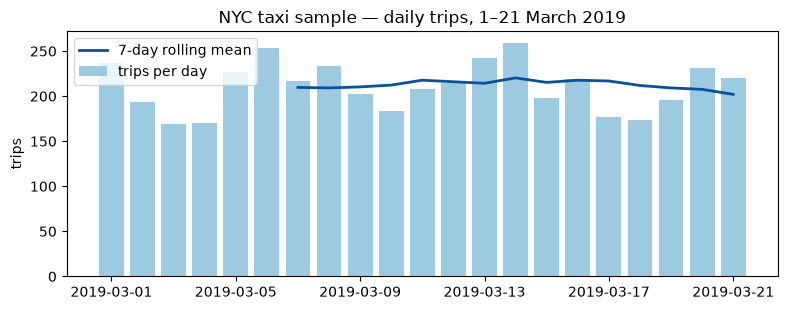

In [60]:
daily = train_trips.resample("D", on="pickup").size().rename("trips").to_frame()
daily["rolling_7d"] = daily["trips"].rolling(7, min_periods=7).mean()
weekday_avg = daily.groupby(daily.index.day_name())["trips"].mean().sort_values(ascending=False)
print("average trips per weekday (train):\n", weekday_avg.round(1), sep="")

fig, ax = plt.subplots(figsize=(8, 3.2))
ax.bar(daily.index, daily["trips"], color="#9ecae1", label="trips per day")
ax.plot(daily.index, daily["rolling_7d"], color="#08519c", linewidth=2, label="7-day rolling mean")
ax.set(title="NYC taxi sample — daily trips, 1–21 March 2019", ylabel="trips")
ax.legend()
plt.tight_layout()
plt.show()

In [61]:
card_train = train_trips[train_trips["payment"] == "credit card"]
tip_table = card_train.pivot_table(index="time_of_day", columns="pickup_borough", values="tip_pct",
                                   aggfunc="median", observed=True).round(3)
print("median tip % of fare (card trips) by time of day × pickup borough:\n", tip_table, sep="")

zone_counts = (
    train_trips.dropna(subset=["pickup_zone"])
    .groupby(["pickup_borough", "pickup_zone"]).size().rename("trips").reset_index()
    .assign(rank=lambda d: d.groupby("pickup_borough")["trips"].rank(method="first", ascending=False).astype(int))
    .loc[lambda d: (d["rank"] <= 3) & (d["pickup_borough"].isin(["Manhattan", "Queens", "Brooklyn"]))]
    .sort_values(["pickup_borough", "rank"])
)
print("\ntop 3 pickup zones per borough:\n", zone_counts.to_string(index=False), sep="")

cash_share = (train_trips["payment"] == "cash").groupby(train_trips["pickup_borough"]).mean().round(3).sort_values()
fare_by_service_zone = train_trips.groupby("pickup_service_zone")["fare"].median().sort_values()
print("\nshare of cash trips by pickup borough:\n", cash_share, sep="")
print("\nmedian fare by pickup service zone:\n", fare_by_service_zone, sep="")

median tip % of fare (card trips) by time of day × pickup borough:
pickup_borough  Bronx  Brooklyn  Manhattan  Queens  Unknown
time_of_day                                                
night             NaN     0.176      0.263   0.215    0.350
morning           0.0     0.000      0.262   0.152    0.362
afternoon         0.0     0.000      0.266   0.205    0.254
evening           0.0     0.212      0.268   0.216    0.235



top 3 pickup zones per borough:
pickup_borough                  pickup_zone  trips  rank
      Brooklyn             Brooklyn Heights     28     1
      Brooklyn                  Fort Greene     27     2
      Brooklyn  Downtown Brooklyn/MetroTech     23     3
     Manhattan               Midtown Center    158     1
     Manhattan        Upper East Side South    154     2
     Manhattan Penn Station/Madison Sq West    150     3
        Queens                  JFK Airport    104     1
        Queens            LaGuardia Airport    100     2
        Queens                      Astoria     41     3



share of cash trips by pickup borough:
pickup_borough
Unknown      0.182
Manhattan    0.259
Bronx        0.262
Brooklyn     0.312
Queens       0.387
Name: payment, dtype: float64

median fare by pickup service zone:
pickup_service_zone
Yellow Zone     9.0
Boro Zone      10.0
Airports       36.0
Name: fare, dtype: float64


### Step 6 — A leakage-free baseline for tip percentage

Predict a card trip's `tip_pct` two ways, using **statistics from the training period only**:
1. **Global baseline:** the training median for every trip.
2. **Group baseline:** the training median of its (pickup borough, time of day) group, falling back to the global median for groups unseen in training.

Then evaluate **once** on the test period with mean absolute error (MAE, the average size of the error).

In [62]:
card_test = test_trips[test_trips["payment"] == "credit card"]
group_keys = ["pickup_borough", "time_of_day"]

global_median = card_train["tip_pct"].median()
group_medians = (card_train.groupby(group_keys, observed=True)["tip_pct"].median()
                 .rename("group_median").reset_index())

scored = (
    card_test
    .merge(group_medians, on=group_keys, how="left", validate="many_to_one")
    .assign(pred_global=global_median,
            pred_group=lambda d: d["group_median"].fillna(global_median))
)
assert len(scored) == len(card_test)

mae_global = mae(scored["tip_pct"], scored["pred_global"])
mae_group = mae(scored["tip_pct"], scored["pred_group"])
unseen_groups = int(scored["group_median"].isna().sum())
print(f"card trips → train {len(card_train):,} | test {len(card_test):,} ({unseen_groups} test trips in groups unseen in training)")
print(f"test MAE — global median: {mae_global:.4f} | group median: {mae_group:.4f}")

card trips → train 3,187 | test 1,362 (0 test trips in groups unseen in training)
test MAE — global median: 0.0823 | group median: 0.0751


### Step 7 — Findings, computed from the data

In [63]:
busiest_day, quietest_day = weekday_avg.idxmax(), weekday_avg.idxmin()
top_zone = zone_counts.sort_values("trips", ascending=False).iloc[0]
card_zero_tip = float((card_train["tip"] == 0).mean())
improvement = 1 - mae_group / mae_global

print(f"1. Data quality: removed {removed} of {len(raw):,} trips ({removed / len(raw):.1%}) — zero distance, "
      f"non-positive duration, speeds over 80 mph, or pickups outside March.")
print(f"2. Cash trips record no tips (mean cash tip = {raw.loc[raw['payment'] == 'cash', 'tip'].mean():.2f}), "
      f"so tip analysis uses the {len(card_train) + len(card_test):,} card trips; even among card trips "
      f"{card_zero_tip:.1%} tipped nothing.")
print(f"3. Demand: {busiest_day} averaged {weekday_avg.max():.0f} trips per day vs {weekday_avg.min():.0f} on "
      f"{quietest_day} ({weekday_avg.max() / weekday_avg.min() - 1:.0%} more) in the training period.")
print(f"4. Busiest pickup zone: {top_zone['pickup_zone']} ({top_zone['pickup_borough']}) with {top_zone['trips']} trips.")
print(f"5. Cash share ranges from {cash_share.min():.0%} ({cash_share.idxmin()}) to {cash_share.max():.0%} ({cash_share.idxmax()}).")
if improvement > 0.01:
    print(f"6. Tip baseline: grouping by borough × time of day cut test MAE by {improvement:.1%} "
          f"({mae_global:.4f} → {mae_group:.4f}).")
else:
    print(f"6. Tip baseline: borough × time of day did not beat the global median on the test period "
          f"(MAE {mae_group:.4f} vs {mae_global:.4f}) — tip rates barely depend on these features.")

1. Data quality: removed 63 of 6,433 trips (1.0%) — zero distance, non-positive duration, speeds over 80 mph, or pickups outside March.
2. Cash trips record no tips (mean cash tip = 0.00), so tip analysis uses the 4,549 card trips; even among card trips 10.2% tipped nothing.
3. Demand: Wednesday averaged 242 trips per day vs 176 on Sunday (37% more) in the training period.
4. Busiest pickup zone: Midtown Center (Manhattan) with 158 trips.
5. Cash share ranges from 18% (Unknown) to 39% (Queens).
6. Tip baseline: grouping by borough × time of day cut test MAE by 8.8% (0.0823 → 0.0751).


**Stretch goals**
1. Add the **dropoff** service zone with a second validated join and check whether airport trips tip differently.
2. Replace the group medians with a scikit-learn model (e.g. gradient boosting on hour, distance, borough) and compare against these baselines on the same time split.
3. Compute a **leakage-safe** rolling feature: for each pickup zone, the number of trips in the *previous* 7 days (shift before rolling).
4. Re-run the whole notebook on a full month of official TLC trip records (Parquet, millions of rows) and note which steps become slow — then try the same analysis in DuckDB.

### 🗣️ How to talk about this in an interview
- "I started with a data-quality audit — duplicates, impossible durations and speeds, zero distances, missing zones — and counted how many rows the cleaning rules removed (about 1% of trips)."
- "I discovered cash trips record zero tips, so I restricted tip analysis to card payments instead of letting that bias every average."
- "Joins were protected with `validate='many_to_one'`, because the official zone lookup has duplicate zone names that would silently duplicate trips."
- "I split by time — train on 1–21 March, test on 22–31 March — and computed every statistic, including group medians and fill values, on the training period only."
- "A simple group-median baseline is my yardstick: any ML model has to beat its test MAE to justify the added complexity."

## 🎤 Interview Q&A

Try answering **out loud** before opening each answer.

### 🧠 Concepts

**Q1. What is the difference between a Series and a DataFrame, and what does the index do?**

<details><summary>Show answer</summary>

- **30-second answer:** A Series is one labelled column; a DataFrame is a table of Series sharing one row index. The index labels rows, enables fast lookups, and **aligns** data by label in arithmetic, assignment, and joins.
- **Go deeper:** Alignment means `s1 + s2` matches labels, not positions — mismatched labels produce `NaN`. After filtering, the index has gaps; `reset_index(drop=True)` renumbers. A `MultiIndex` holds several levels (e.g. day and time after a two-key groupby).
- **❌ Common wrong answer:** "The index is just the row number."

</details>

**Q2. `loc` vs `iloc`?**

<details><summary>Show answer</summary>

- **30-second answer:** `loc` selects by label (and boolean masks), and label slices *include* the end; `iloc` selects by integer position, and slices *exclude* the end, like Python lists.
- **Go deeper:** `df.loc[0:2]` returns 3 rows on a default index, `df.iloc[0:2]` returns 2. After sorting or filtering, label 0 may not be at position 0. Use `loc` for assignment: `df.loc[mask, "col"] = value`.
- **❌ Common wrong answer:** "They're the same, `iloc` is just faster."

</details>

**Q3. What is Copy-on-Write, and what changed in pandas 3.0?**

<details><summary>Show answer</summary>

- **30-second answer:** In pandas 3.0 Copy-on-Write is always on: any object derived from another behaves as an independent copy, but the actual copy is delayed until one of them is modified. So modifying a subset never changes the parent, `SettingWithCopyWarning` is gone, and chained assignment (`df[mask]["col"] = v`) never works.
- **Go deeper:** Use `df.loc[mask, "col"] = v` or reassign (`df["col"] = df["col"].fillna(0)`). `df["col"].fillna(0, inplace=True)` does not update `df` (pandas warns with `ChainedAssignmentError`). pandas 3.0 also made the `str` dtype the default for text instead of `object`.
- **❌ Common wrong answer:** "Just add `.copy()` everywhere to silence the warning."

</details>

**Q4. `agg` vs `transform` vs `filter` in a groupby?**

<details><summary>Show answer</summary>

- **30-second answer:** `agg` returns one row per group (summaries); `transform` returns a result with the original row count, aligned to the rows (adding group statistics as features); `filter` keeps or drops *whole groups* based on a condition.
- **Go deeper:** `df["x"] / df.groupby("k")["x"].transform("sum")` gives share of group total without a merge. Named aggregation (`agg(n=("x", "size"))`) gives clean column names. `apply` is the flexible, slow fallback.
- **❌ Common wrong answer:** "`transform` is the same as `apply`."

</details>

**Q5. Why is `df.apply(func, axis=1)` slow, and when is it acceptable?**

<details><summary>Show answer</summary>

- **30-second answer:** It calls a Python function once per row, creating a Series for each row, so it runs at Python speed — often hundreds of times slower than vectorized column operations. It's acceptable for small data or logic that genuinely can't be vectorized (calling an external parser, complex string logic on a few thousand rows).
- **Go deeper:** Replace with column arithmetic, `np.where`/`np.select`, `Series.map`, `pd.cut`, `.str`/`.dt` accessors, or `groupby` + `transform`. For heavy custom logic consider Numba, DuckDB, or Polars.
- **❌ Common wrong answer:** "`apply` is vectorized because it's a pandas method."

</details>

**Q6. How do you handle missing values in a dataset you'll use for ML?**

<details><summary>Show answer</summary>

- **30-second answer:** Quantify them (`isna().mean()`), understand why they're missing, then drop, fill (constant, median, per-group, forward-fill for time series) or let the model handle them — often adding a missing-indicator column. Fill statistics are learned on the training split only and reused on validation/test.
- **Go deeper:** Missing-not-at-random values carry signal (e.g. "income not reported"). Wrap imputation in a scikit-learn `Pipeline` so cross-validation refits it per fold. Nullable dtypes (`Int64`) keep integer columns integers.
- **❌ Common wrong answer:** "Fill everything with the mean of the whole dataset" — that leaks test information and ignores why values are missing.

</details>

### 💻 Coding

**Q7. Return the top 3 products by revenue within each category.**

<details><summary>Show answer</summary>

- **30-second answer:** `df.sort_values(["category", "revenue"], ascending=[True, False]).groupby("category").head(3)`, or add `rank = df.groupby("category")["revenue"].rank(method="first", ascending=False)` and filter `rank <= 3`.
- **Go deeper:** Discuss ties (`method="min"` keeps ties, `"dense"` doesn't skip ranks) and that the SQL equivalent is `ROW_NUMBER() OVER (PARTITION BY category ORDER BY revenue DESC)`. `groupby(...)["revenue"].nlargest(3)` also works but returns a MultiIndex.
- **❌ Common wrong answer:** `df.nlargest(3, "revenue")` — that's the top 3 overall, not per category.

</details>

**Q8. For an orders table, compute each customer's days since their previous order and a rolling 3-order average spend.**

<details><summary>Show answer</summary>

- **30-second answer:** Sort by customer and timestamp; `g = df.groupby("customer")`; `df["days_since_prev"] = g["ts"].diff().dt.days`; `df["avg_spend_3"] = g["amount"].transform(lambda s: s.rolling(3, min_periods=1).mean())`.
- **Go deeper:** For an ML feature that predicts the current order, shift first: `s.shift(1).rolling(3).mean()` so a row doesn't include itself. Time-based windows use `rolling("30D", on="ts")` on a sorted datetime column.
- **❌ Common wrong answer:** Calling `df["ts"].diff()` without grouping — it subtracts across different customers.

</details>

**Q9. Convert a wide table of monthly sales (one column per month) into a long table, and back.**

<details><summary>Show answer</summary>

- **30-second answer:** Wide → long: `df.melt(id_vars="store", var_name="month", value_name="sales")`. Long → wide: `long.pivot(index="store", columns="month", values="sales")`, or `pivot_table(..., aggfunc="sum")` if (store, month) pairs repeat.
- **Go deeper:** `pivot` raises on duplicate pairs; `pivot_table` aggregates. Column order after pivoting is sorted — reorder months explicitly. Long ("tidy") format is what plotting libraries and most ML code expect.
- **❌ Common wrong answer:** Looping over months and concatenating DataFrames by hand.

</details>

### 🐛 Debugging Scenarios

**Q10. After merging orders (1M rows) with a customer table, you have 1.3M rows. What happened and how do you fix it?**

<details><summary>Show answer</summary>

- **30-second answer:** The customer table has duplicate keys, so each order matched several customer rows (m × n per key). Find them with `customers["customer_id"].duplicated().sum()`, deduplicate or fix the source, and enforce with `merge(..., validate="many_to_one")`.
- **Go deeper:** Also check key dtypes (`"42"` vs `42`), whitespace/case in string keys, and that pandas matches `NaN` keys to each other. Assert `len(result) == len(orders)` after every left join in a pipeline.
- **❌ Common wrong answer:** "Just call `drop_duplicates()` on the result" — it hides the bug and may drop legitimate identical orders.

</details>

**Q11. A teammate runs `df[df["age"] > 60]["segment"] = "senior"` and `df["age"].fillna(0, inplace=True)`, but `df` doesn't change. Why?**

<details><summary>Show answer</summary>

- **30-second answer:** Both are chained operations: the first indexing step creates a new object, and the assignment or in-place fill modifies that temporary object. Under Copy-on-Write (pandas 3) this never updates `df`. Use `df.loc[df["age"] > 60, "segment"] = "senior"` and `df["age"] = df["age"].fillna(0)`.
- **Go deeper:** pandas emits a `ChainedAssignmentError` warning for these patterns. In pandas < 3 the behaviour depended on whether the intermediate was a view or a copy, which is exactly why CoW was introduced.
- **❌ Common wrong answer:** "It's a pandas bug; add `.copy()`."

</details>

**Q12. Loading a 6 GB CSV crashes your 16 GB laptop. What do you try?**

<details><summary>Show answer</summary>

- **30-second answer:** Read only needed columns (`usecols`), set compact dtypes up front (`category`, `float32`, smaller ints), parse in chunks (`chunksize`) and aggregate per chunk, and convert to Parquet once. If it's still too big, query it with DuckDB or Polars' lazy engine, which stream data and use all cores.
- **Go deeper:** `engine="pyarrow"` speeds up parsing; `memory_usage(deep=True)` shows what's heavy (usually text columns). Text in object dtype is the classic memory hog — pandas 3's Arrow-backed `str` dtype helps.
- **❌ Common wrong answer:** "Buy more RAM" or "use `df.apply` in a loop to process it row by row".

</details>

**Q13. `df.groupby("country")["user_id"].count().sum()` is smaller than `len(df)`. Where did the rows go?**

<details><summary>Show answer</summary>

- **30-second answer:** Two things silently drop rows: `groupby` excludes rows whose key (`country`) is `NaN` by default, and `count` skips `NaN` values in `user_id`. Use `groupby("country", dropna=False)` and `size()` to count rows.
- **Go deeper:** `value_counts()` also drops `NaN` unless `dropna=False`. Reconcile totals after every aggregation — a check like `assert grouped.sum() == len(df)` catches this immediately.
- **❌ Common wrong answer:** "`count` and `size` are the same."

</details>

### 🏗️ Design

**Q14. When would you stop using pandas and switch to SQL/DuckDB, Polars, or Spark?**

<details><summary>Show answer</summary>

- **30-second answer:** pandas is ideal for data that fits comfortably in memory on one machine and for interactive exploration. For larger-than-memory or heavy analytical queries on one machine, DuckDB or Polars (multi-threaded, lazy, streaming). For data that needs a cluster (hundreds of GB+) or already lives in a lakehouse, Spark or the warehouse's SQL.
- **Go deeper:** pandas is mostly single-threaded and eager; DuckDB/Polars optimise whole queries (predicate/projection pushdown) and read Parquet directly. Many teams mix them: SQL for heavy aggregation, pandas for the final feature table and modelling. Arrow lets data move between them with little copying.
- **❌ Common wrong answer:** "pandas can't handle more than a million rows" or "always use Spark for production".

</details>

**Q15. Design a feature table for predicting whether a user will churn next month from an events log. How do you avoid leakage?**

<details><summary>Show answer</summary>

- **30-second answer:** Pick a cutoff date per training example; build features only from events *before* the cutoff (counts, recency via `groupby` + `max`/`diff`, rolling activity with shift-then-rolling) and the label from the period *after* it. Split train/validation/test by time, and learn all fill values and encodings on the training period only.
- **Go deeper:** Use point-in-time joins (`pd.merge_asof` on timestamps) for slowly changing attributes, protect joins with `validate=`, and version the feature code so training and serving compute features identically (a feature store helps). Check for target leakage by looking for suspiciously predictive features.
- **❌ Common wrong answer:** "Compute features over the whole history and do a random 80/20 split."

</details>

## 🧪 Quick Quiz

Predict the output, then reveal.

**1.** `pd.Series([1, 2, 3], index=["a", "b", "c"]) + pd.Series([10, 20], index=["b", "c"])`
<details><summary>Answer</summary>

`a NaN, b 12.0, c 23.0` — values align by label; `a` has no partner, so it's `NaN` (and the dtype becomes float).
</details>

**2.** With `df = pd.DataFrame({"x": range(5)})`, how many rows do `df.loc[0:2]` and `df.iloc[0:2]` return?
<details><summary>Answer</summary>

`3` and `2` — `loc` label slices include the end label; `iloc` position slices don't.
</details>

**3.** What is `pd.Series([1, None]).dtype`?
<details><summary>Answer</summary>

`float64` — NumPy integers can't hold `NaN`, so pandas upcasts. `pd.Series([1, None], dtype="Int64")` keeps integers with `<NA>`.
</details>

**4.** `df = pd.DataFrame({"k": ["a", "a", "b"], "v": [1, 2, 3]})`. What are `df.groupby("k")["v"].transform("sum").tolist()` and `df.groupby("k")["v"].agg("sum").tolist()`?
<details><summary>Answer</summary>

`[3, 3, 3]` and `[3, 3]` — `transform` keeps one value per original row; `agg` returns one per group.
</details>

**5.** In pandas 3, after `df = pd.DataFrame({"a": [1, 2, 3], "b": [4, 5, 6]})` and `df[df["a"] > 1]["b"] = 0`, what is `df["b"].tolist()`?
<details><summary>Answer</summary>

`[4, 5, 6]` — chained assignment modifies a temporary object and never the original (pandas warns with `ChainedAssignmentError`). Use `df.loc[df["a"] > 1, "b"] = 0`.
</details>

## 📚 Resources

### 📖 Official Docs
- [10 minutes to pandas](https://pandas.pydata.org/docs/user_guide/10min.html) — the official quick tour
- [Copy-on-Write (CoW)](https://pandas.pydata.org/docs/user_guide/copy_on_write.html) — the pandas 3 rules for copies, views, and chained assignment
- [What's new in 3.0.0](https://pandas.pydata.org/docs/whatsnew/v3.0.0.html) · [Migration guide for the new string data type](https://pandas.pydata.org/docs/user_guide/migration-3-strings.html)
- [Group by: split-apply-combine](https://pandas.pydata.org/docs/user_guide/groupby.html) · [Windowing operations](https://pandas.pydata.org/docs/user_guide/window.html)
- [Merge, join, concatenate and compare](https://pandas.pydata.org/docs/user_guide/merging.html) · [Reshaping and pivot tables](https://pandas.pydata.org/docs/user_guide/reshaping.html)
- [Working with missing data](https://pandas.pydata.org/docs/user_guide/missing_data.html) · [Time series / date functionality](https://pandas.pydata.org/docs/user_guide/timeseries.html)
- [Comparison with SQL](https://pandas.pydata.org/docs/getting_started/comparison/comparison_with_sql.html) · [Enhancing performance](https://pandas.pydata.org/docs/user_guide/enhancingperf.html)

### 🎥 Videos
- [Keith Galli — Complete Python Pandas Data Science Tutorial! (2025 Updated Edition)](https://www.youtube.com/watch?v=2uvysYbKdjM) (1 h 34 min) — a hands-on, recently updated walkthrough of loading, filtering, grouping, and merging real data; a great second pass after this notebook
- [Data School (Kevin Markham) — My top 25 pandas tricks](https://www.youtube.com/watch?v=RlIiVeig3hc) (28 min) — short, practical idioms you'll use daily; check any API it shows against the pandas 3 docs, since it predates Copy-on-Write
- [Corey Schafer — Pandas Tutorials (playlist)](https://www.youtube.com/playlist?list=PL-osiE80TeTsWmV9i9c58mdDCSskIFdDS) — clear, slower-paced videos per topic (filtering, grouping, dates, cleaning) if a section here didn't click

### 📄 Papers
- [Hadley Wickham (2014) — Tidy Data, *Journal of Statistical Software*](https://www.jstatsoft.org/article/view/v059i10) — the idea behind long vs wide tables and why `melt`/`pivot` exist
- [Wes McKinney (2010) — Data Structures for Statistical Computing in Python, SciPy Proceedings](https://proceedings.scipy.org/articles/Majora-92bf1922-00a) — the original pandas paper from its creator

### 📘 Books & Courses
- [Python for Data Analysis, 3E (free online)](https://wesmckinney.com/book/) — Wes McKinney, the creator of pandas
- [Python Data Science Handbook — Data Manipulation with Pandas (free online)](https://jakevdp.github.io/PythonDataScienceHandbook/03.00-introduction-to-pandas.html) — Jake VanderPlas
- [Kaggle Learn — Pandas](https://www.kaggle.com/learn/pandas) — a free, short interactive course with graded exercises

### 🏋️ Practice
- [pandas_exercises (GitHub)](https://github.com/guipsamora/pandas_exercises) — notebooks of exercises on real datasets, with solutions
- [StrataScratch](https://www.stratascratch.com/) — real interview questions from tech companies, solvable in pandas or SQL

## 📝 Summary Cheat Sheet

| Concept | What it does | Key API / rule |
|---|---|---|
| Series / DataFrame | labelled column / table | `pd.Series`, `pd.DataFrame`, `set_index`, alignment by label |
| Load & explore | read and profile data | `read_csv`, `read_parquet(columns=)`, `info`, `describe`, `value_counts(normalize=True)` |
| Select | rows & columns | `loc` (labels, end included), `iloc` (positions), `(a) & (b)`, `query`, `isin`, `between` |
| Create columns | readable pipelines | `assign`, `pd.col`, `pipe`, `sort_values`; Copy-on-Write → `df.loc[mask, col] = v` |
| Missing data | detect & fill | `isna`, `dropna`, `fillna({col: train_stat})` — statistics from **train only** |
| dtypes | right type per column | `str` (default text), `category` (ordered), `datetime64`, `Int64`, `to_numeric(errors="coerce")` |
| Text & dates | vectorized accessors | `.str.contains/split/extract`, `.dt.hour/day_name/total_seconds`, `tz_localize` |
| GroupBy | split-apply-combine | `agg(name=(col, fn))`, `transform` (same length), `filter` (whole groups), `dropna=False` |
| Window functions | per-row values over a group | sort → `groupby` + `rank`, `shift`, `diff`, `cumsum`, `cummax`, `rolling`; shift before rolling for features |
| Joins | combine tables | `merge(how=, validate="many_to_one", indicator=True)`; m × n rows per duplicate key |
| Reshape | long ↔ wide | `pivot`, `pivot_table(aggfunc=, margins=)`, `melt`, `stack`/`unstack`, `crosstab` |
| Time series | time buckets & smoothing | `resample("D"/"ME"/"YE", on=)`, `rolling(7)`, `pct_change` |
| Performance | stay vectorized | column math, `np.where`/`np.select`, `map`, `pd.cut`; avoid `apply(axis=1)`/`iterrows` |
| SQL ↔ pandas | same ideas, two syntaxes | `WHERE`→mask, `GROUP BY`→`groupby.agg`, `HAVING`→filter after agg, `ROW_NUMBER`→`cumcount()+1`, `LAG`→`shift` |

## ➡️ What's Next

**[03 · SQL with DuckDB](03_SQL_with_DuckDB.ipynb)** — you've seen that every pandas operation has a SQL twin; next you'll write that SQL directly (joins, window functions, CTEs) with DuckDB, which runs on the same DataFrames and Parquet files but scales past memory and is what most data teams and interviews use.